# Лабораторная работа 3 — классификация временных рядов и прогнозирование метеоданных
      
**Студентки Холиной Елены**     

**Цель:** анализ почасовых метеорядов по шести городам (Open-Meteo, 2019–2025 гг.), классификация климатической зоны методом временных рядов (KNN-DTW), прогноз температуры по городам (LightGBM, RandomForest), оценка качества моделей и объединение этапов в единый пайплайн.

**Зависимости:** `pip install -r requirements.txt`. **Исходные данные:** каталог `data/`, файлы parquet по городам.

Документ содержит **выводы по пунктам 2.1–2.8** и **общий итог**. Графики и текстовые отчёты сохраняются в `results/`figures

---
### Соответствие разделов заданию

| Раздел ноутбука | Пункт задания |
|----------------|---------------|
| Разведочный анализ | 2.1 |
| Инжиниринг признаков | 2.2 |
| Классификация (KNN-DTW, baseline RF) | 2.3 |
| Метрики классификации | 2.4 |
| Прогноз по городам | 2.5 |
| Метрики прогноза, остатки, графики | 2.6 |
| Единый пайплайн | 2.7 |
| Сводка результатов и выводы | 2.8 |

## 2.1 Разведочный анализ (EDA)

Выполняется построение графиков и расчёт ADF-тестов с сохранением результатов в `results/figures`.


### Итог по разделу 2.1 (EDA)

По метеорядам шести городов за 2019–2025 гг. на графиках не видно длительных разрывов во времени; ряды выглядят непрерывными и пригодными для построения скользящих окон и лагов. Долю пропусков при необходимости количественно оценивают по доле `NaN` по столбцам.
Температура у всех городов показывает ярко выраженную **годовую сезонность** с повторяющимися летними максимумами и зимними минимумами, а также заметную **высокочастотную изменчивость**, что согласуется с почасовой дискретизацией и обосновывает ресемплинг до суток, если требуется интерпретировать горизонт в календарных днях.

**Благовещенск** выделяется наибольшей **контрастностью сезона** (очень холодные зимы и жаркое лето), что соответствует ожидаемому для континентально-муссонного режима профилю; **Москва и Санкт-Петербург** демонстрируют типичный умеренный ход с выраженным снежным сезоном по `snowfall` и могут частично **пересекаться по температурным условиям** в переходные сезоны.

**Геленджик** показывает более мягкую зиму и выраженное летнее тепло, а осадки по `precipitation`/`rain` имеют характер редких крупных событий на фоне нулей; **Находка** также проявляет выраженную сезонность и штормовую изменчивость ветра.

Ряды осадков и мгновенных осадковых компонент выглядят **сильно асимметричными** и не похожими на нормальное распределение, что поддерживает выбор устойчивых к выбросам моделей на этапе прогноза и признаков-агрегатов по окнам на этапе классификации.

Тест Дики-Фуллера по `temperature_2m` для всех городов даёт **p-value < 0.05**, то есть формально отвергается наличие единичного корня в смысле ADF; при этом **видимая сезонность на графиках сохраняется**, поэтому ADF не отменяет необходимость календарных и циклических признаков в моделях.

**Обработка данных:** короткие пропуски во временных рядах допускается восполнять локальной интерполяцией с ограничением по окну; выбросы по осадкам и ветру целесообразно трактовать как возможные **экстремальные явления** и не удалять автоматически без метеорологического обоснования.

Города: ['Москва', 'Сочи', 'Благовещенск', 'Находка', 'Геленджик', 'Санкт-Петербург']


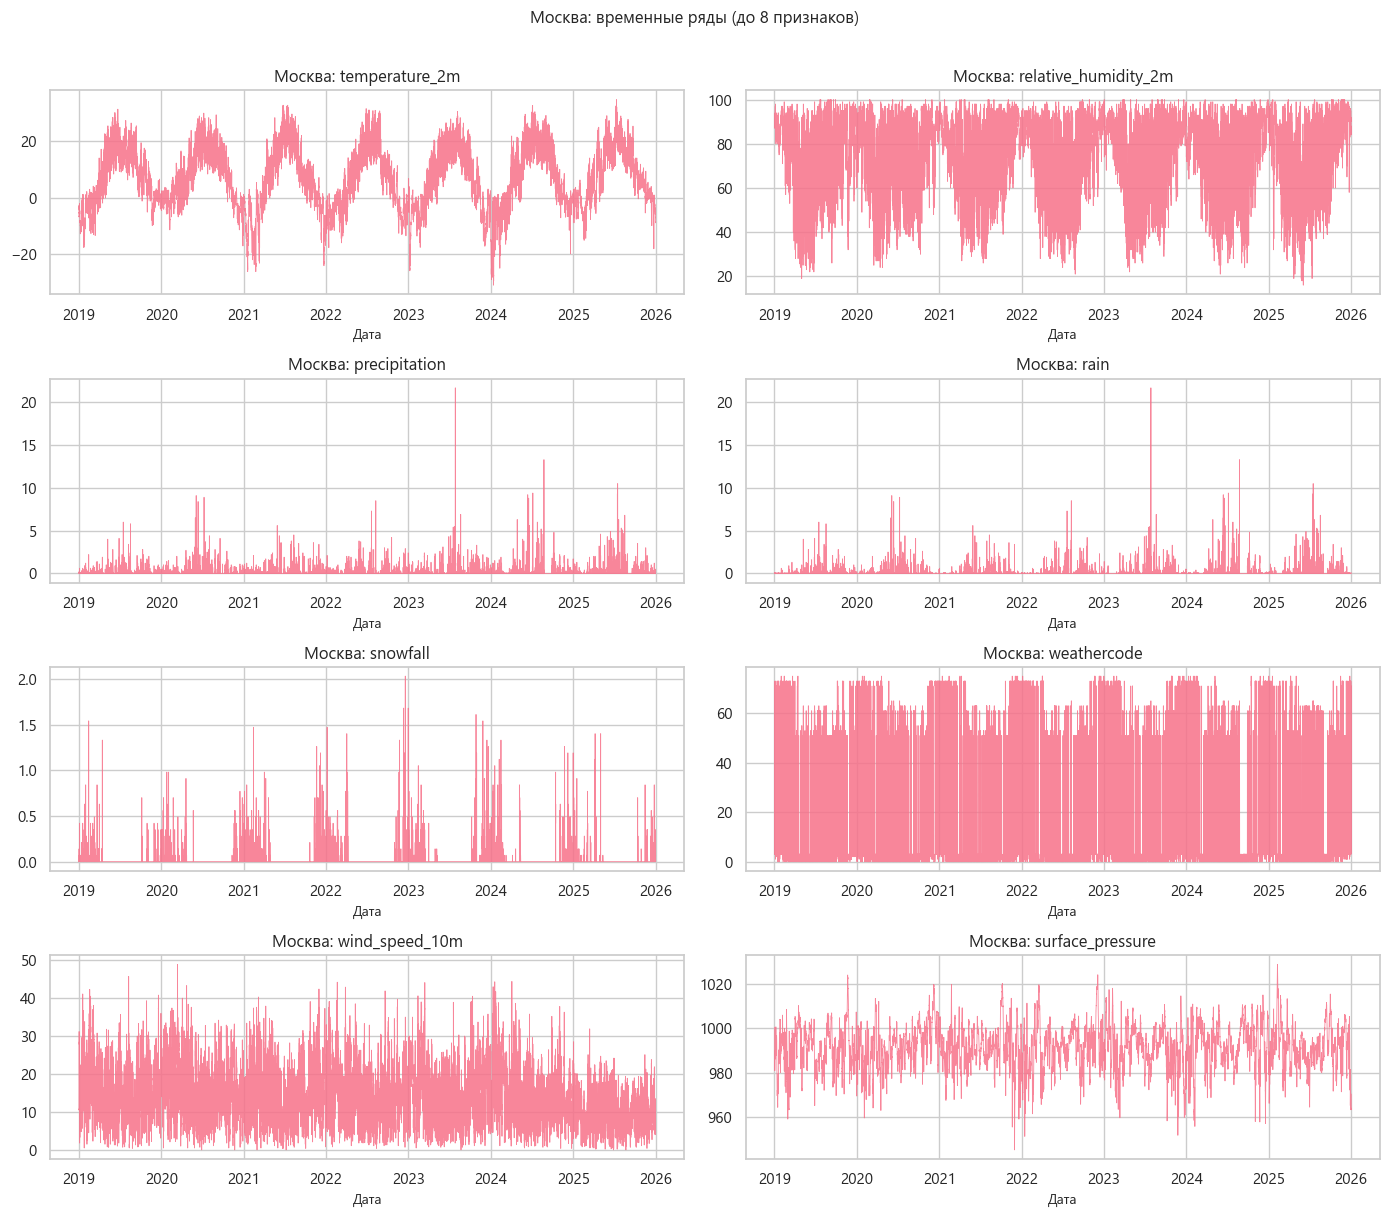

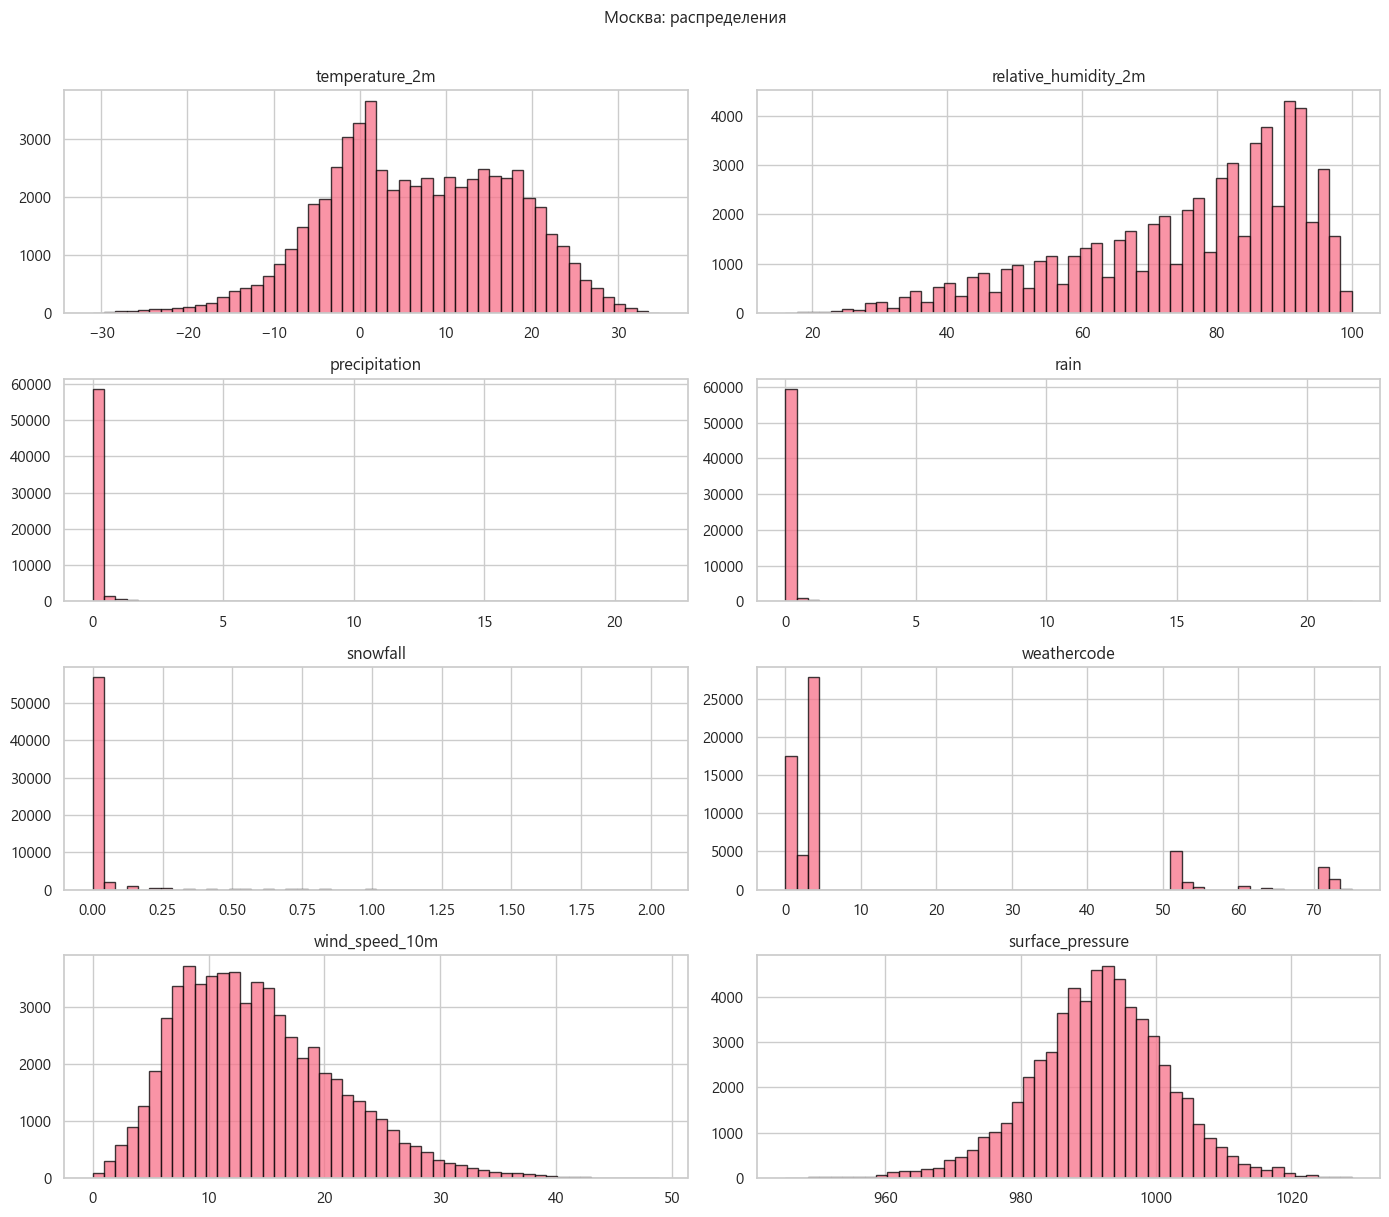

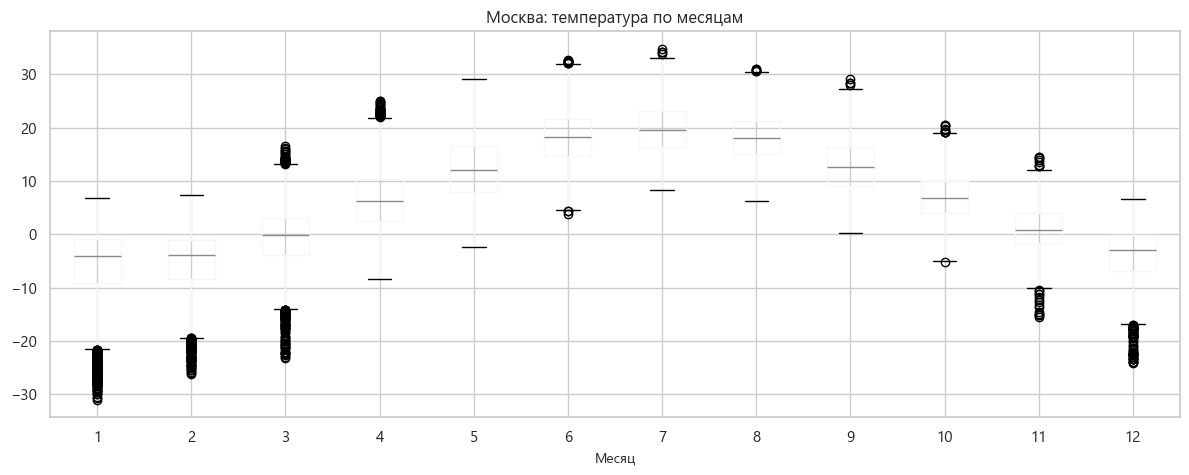

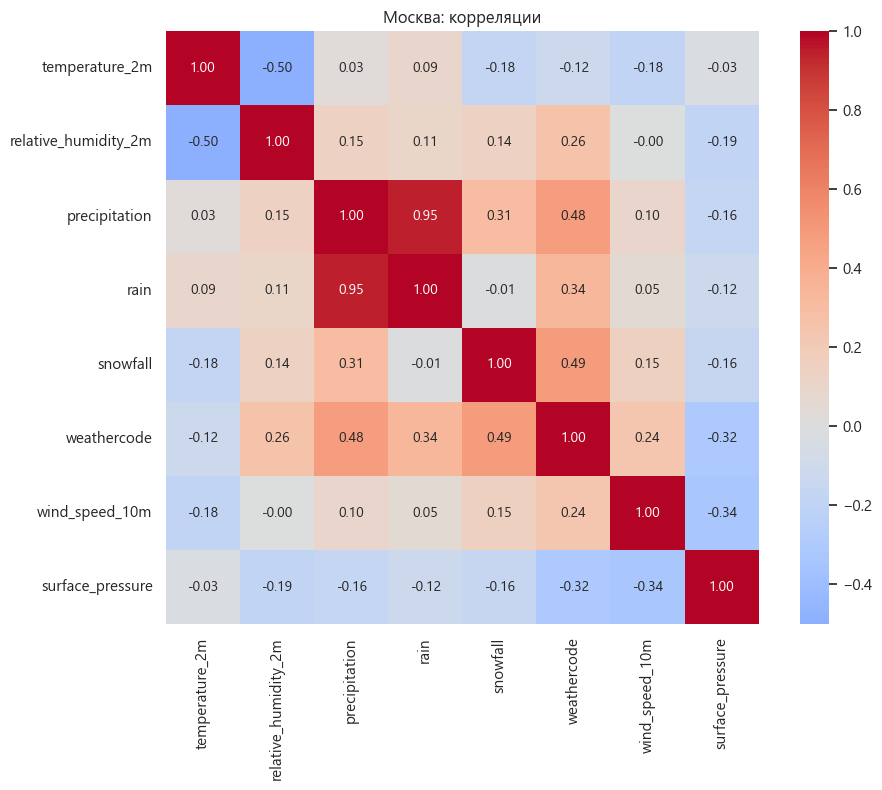

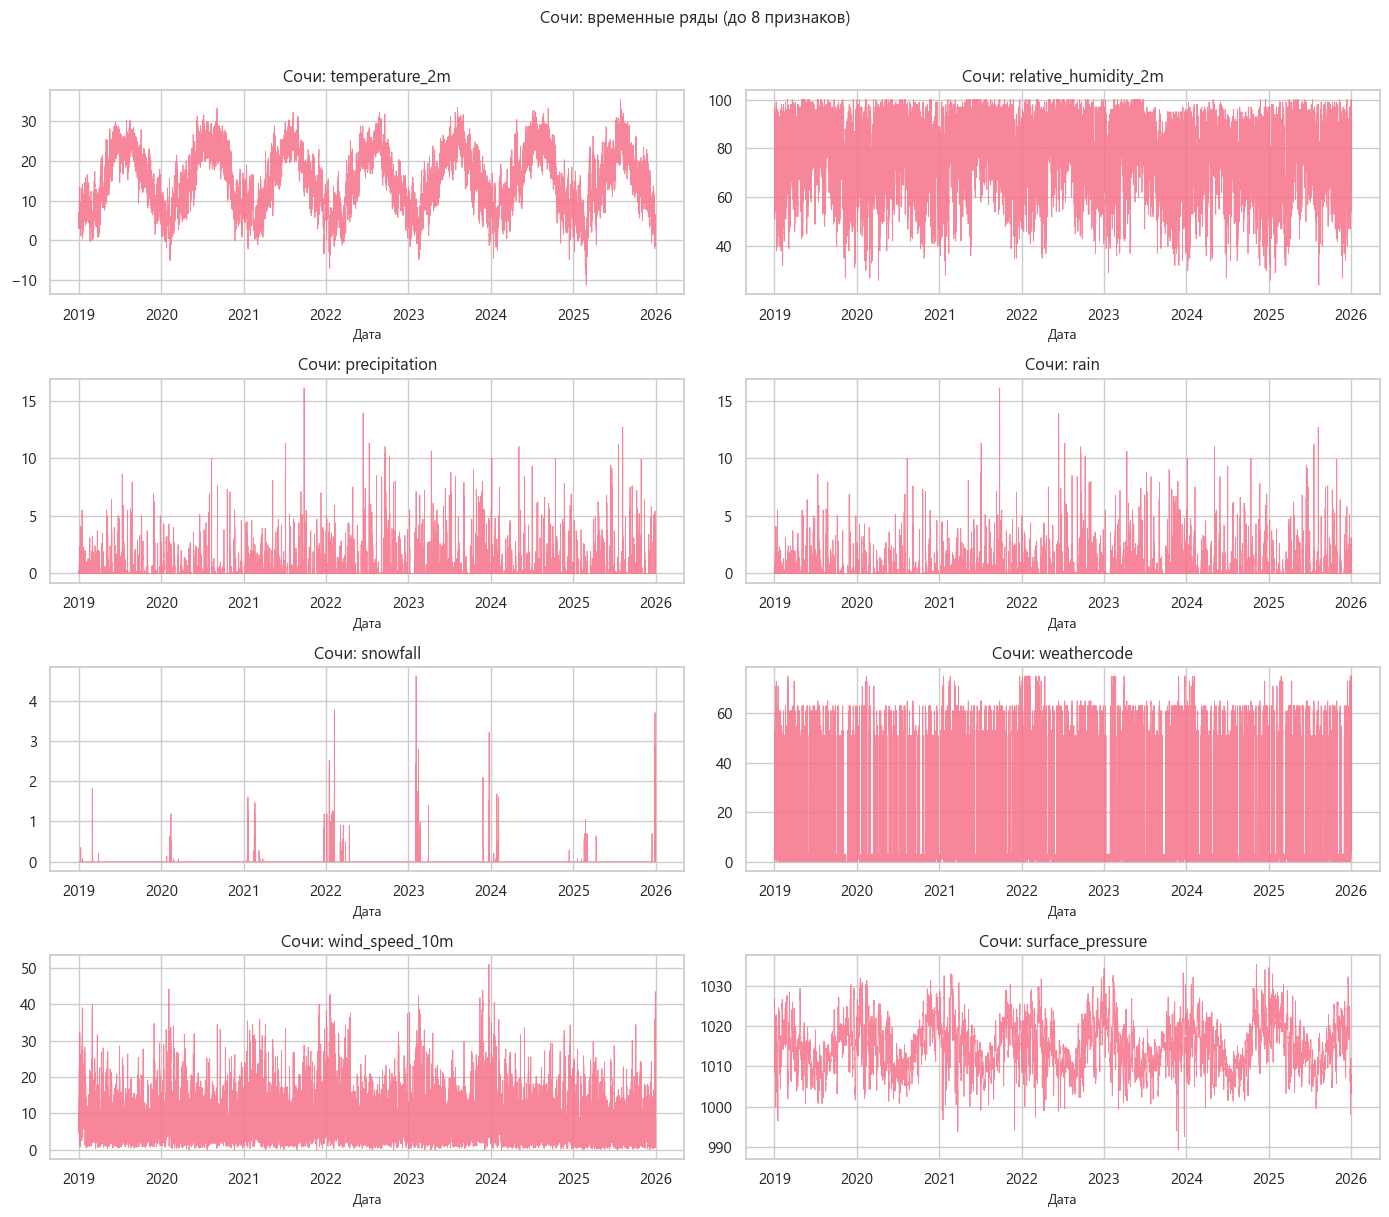

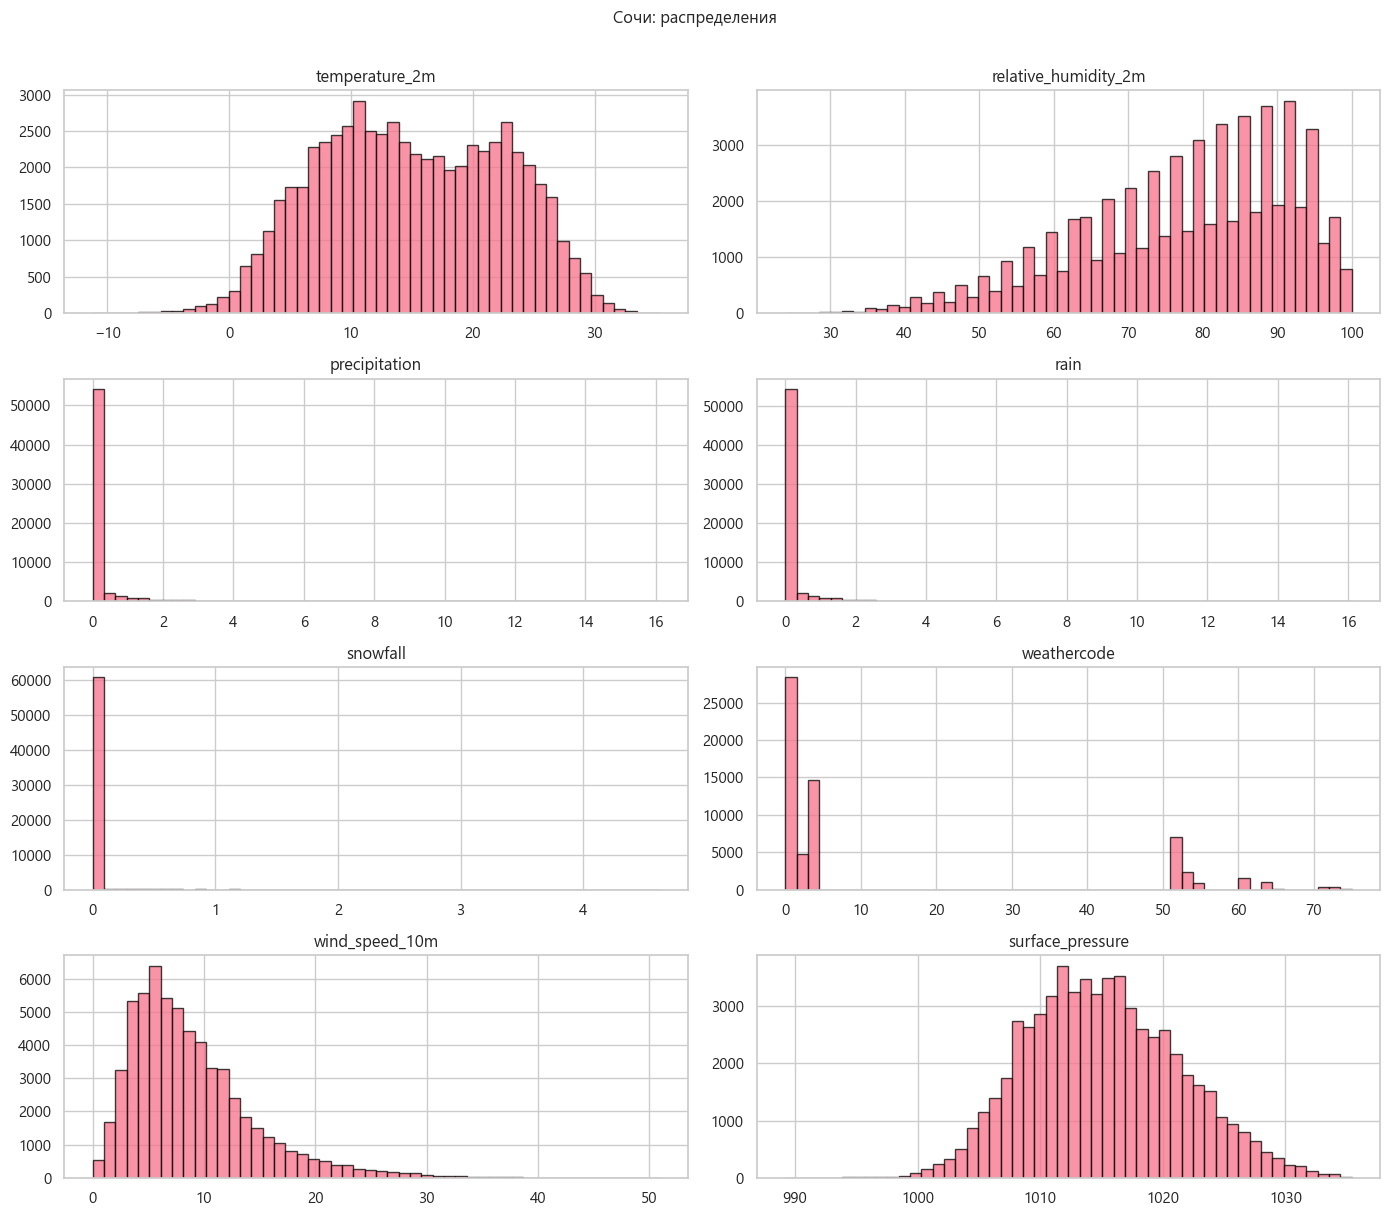

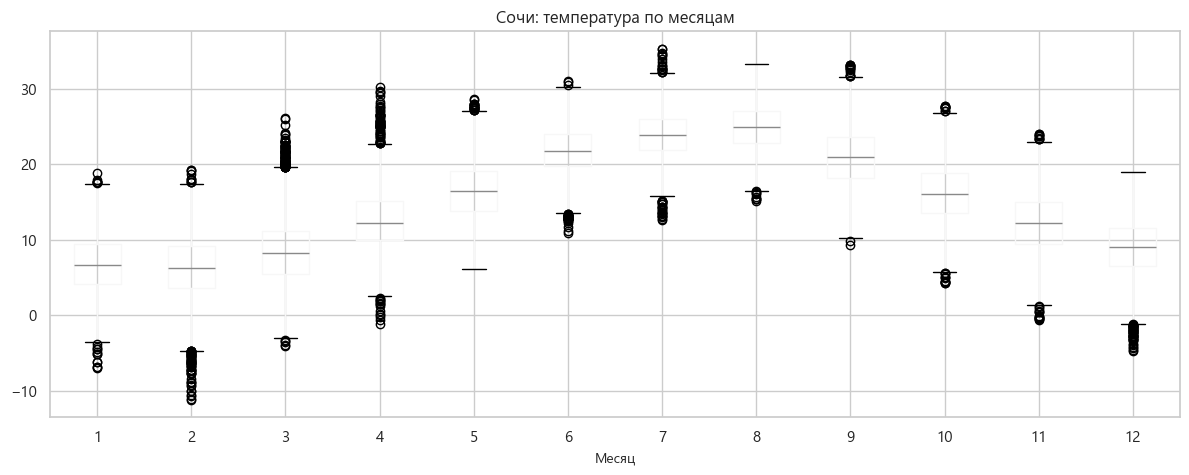

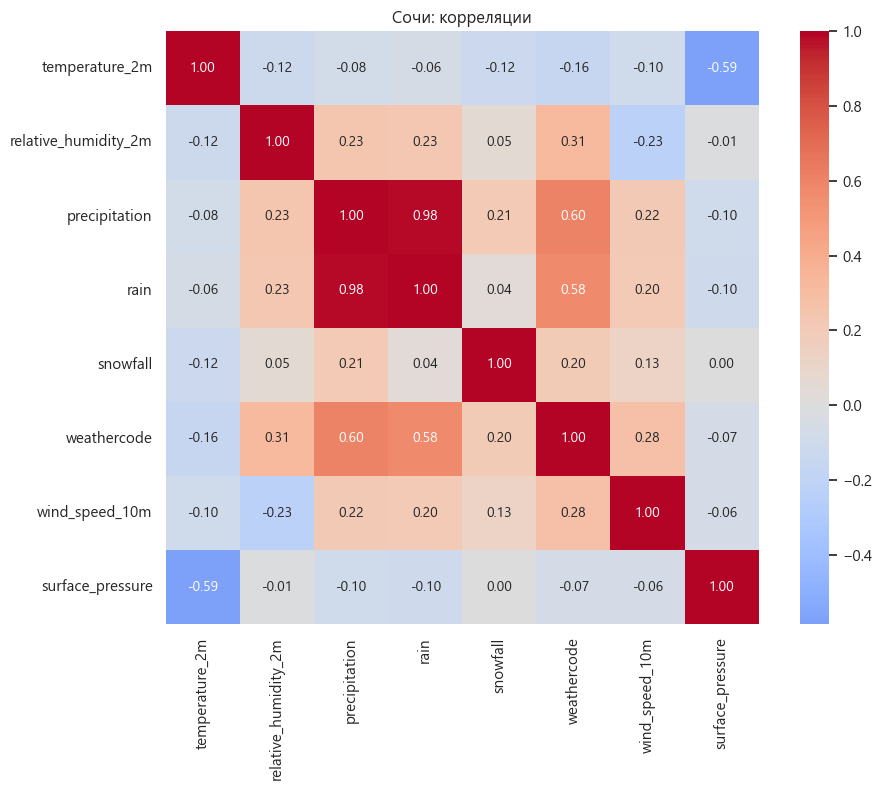

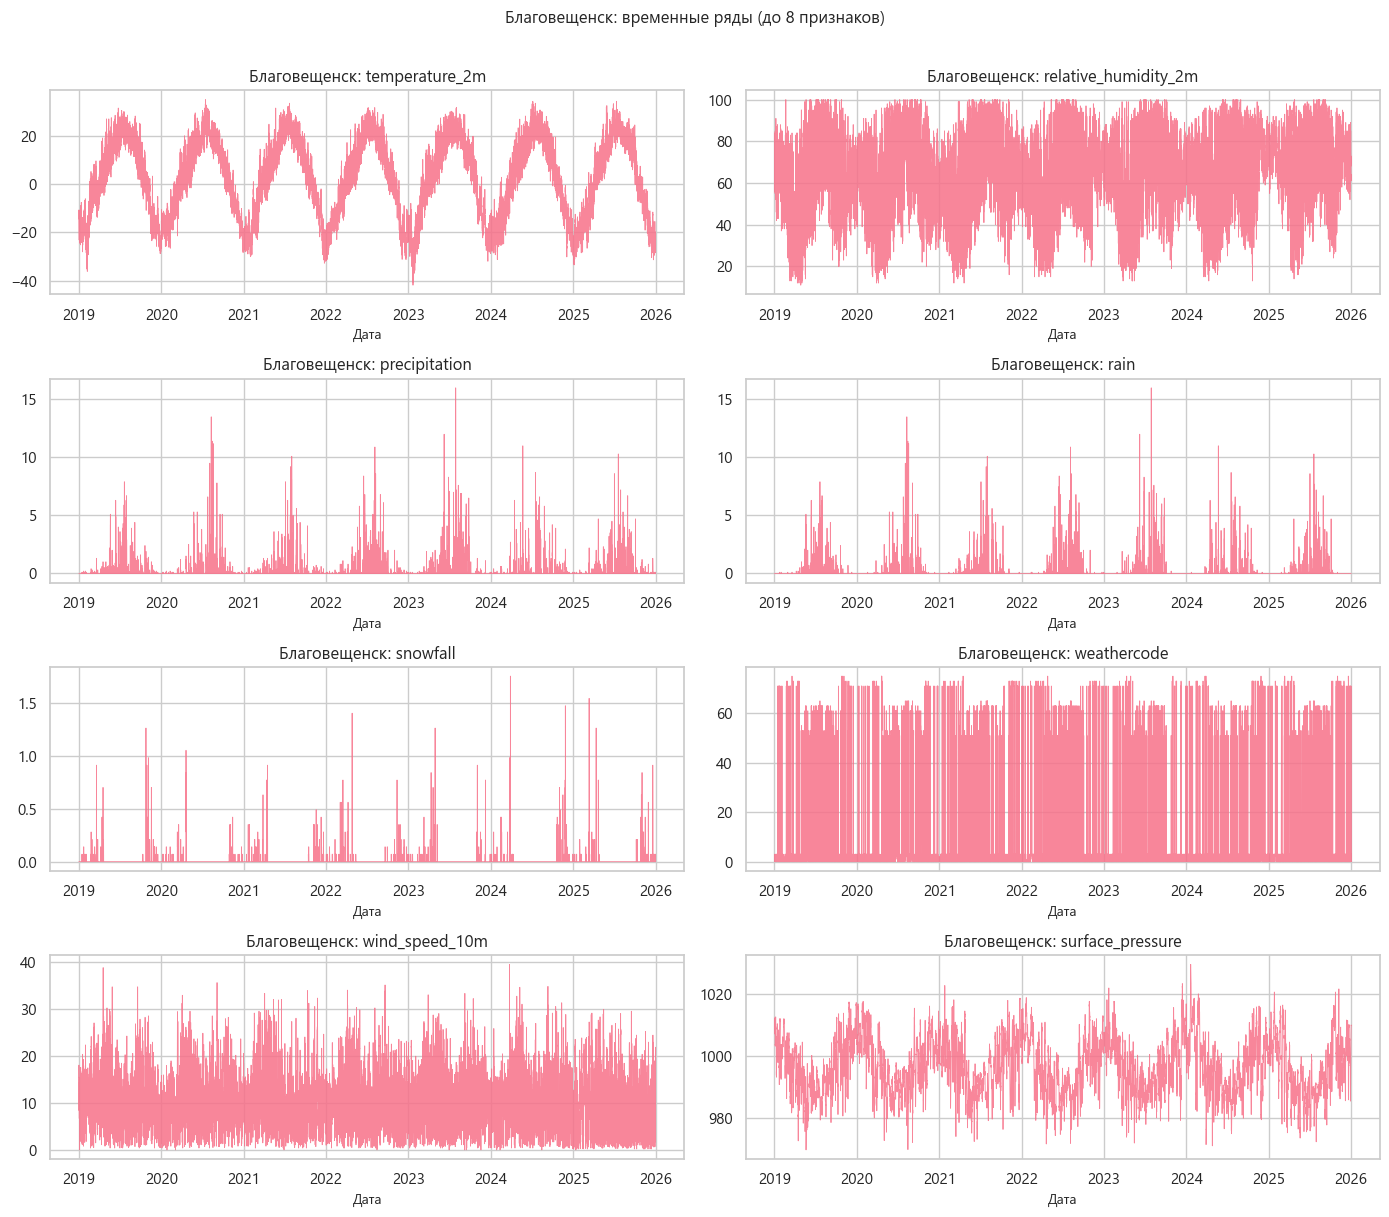

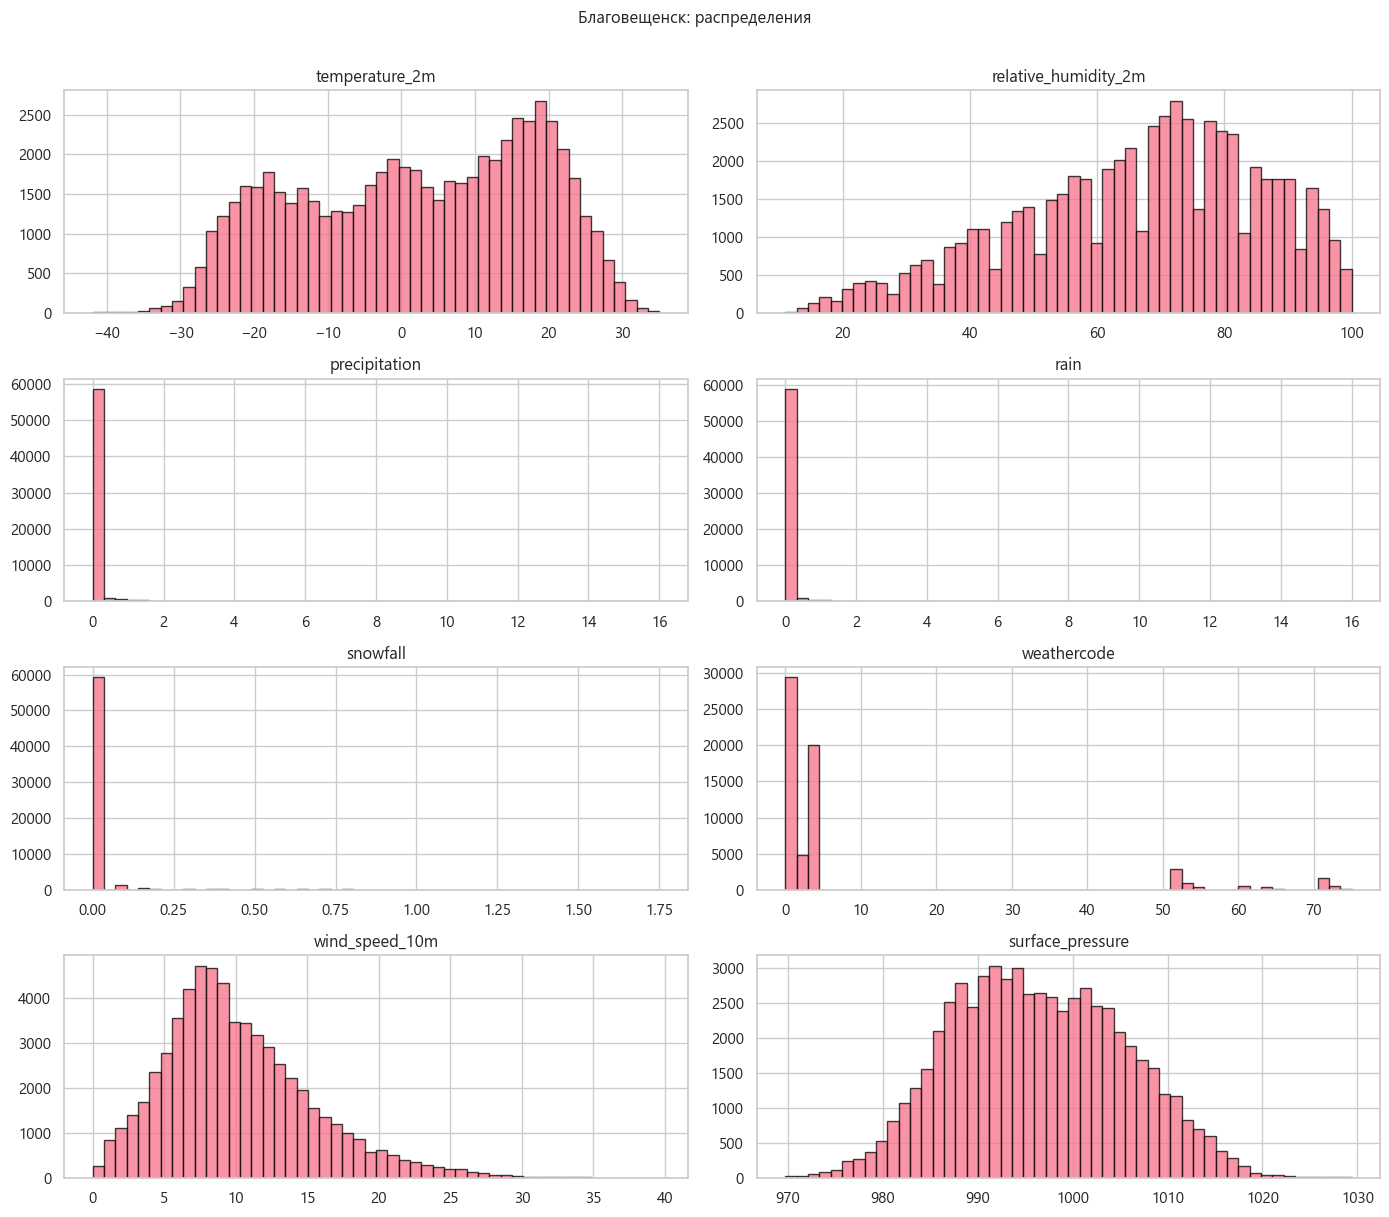

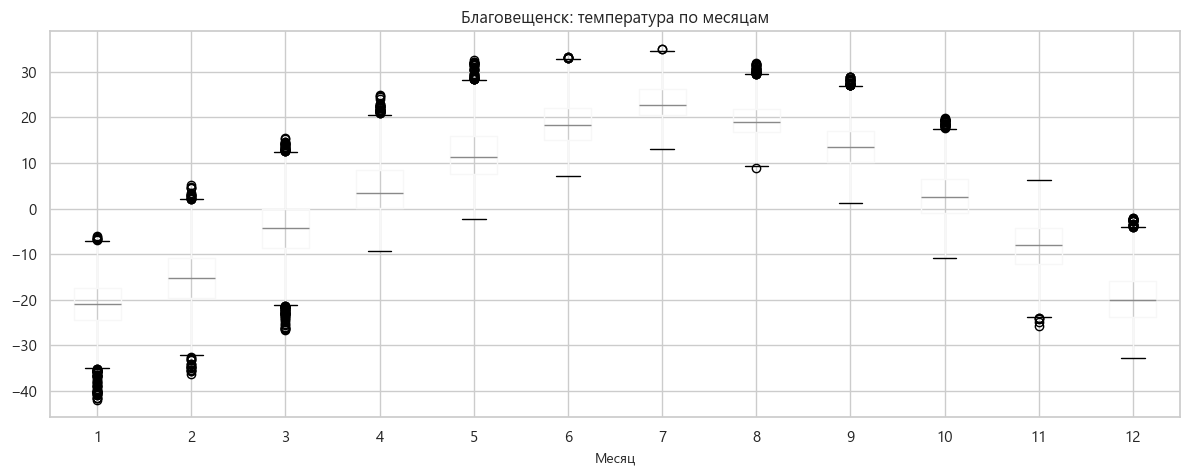

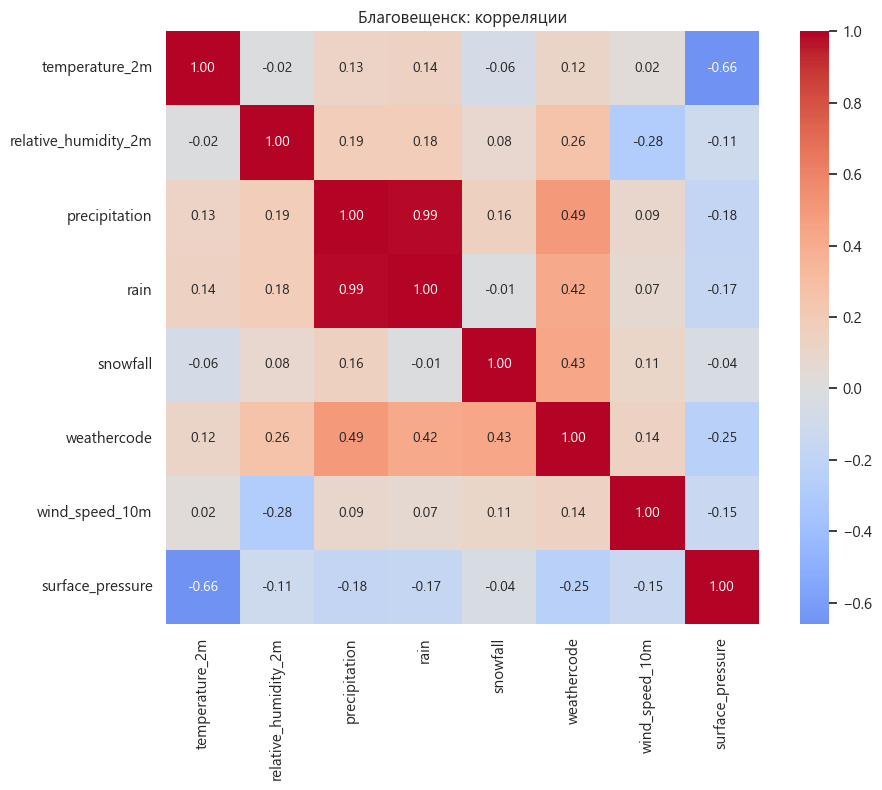

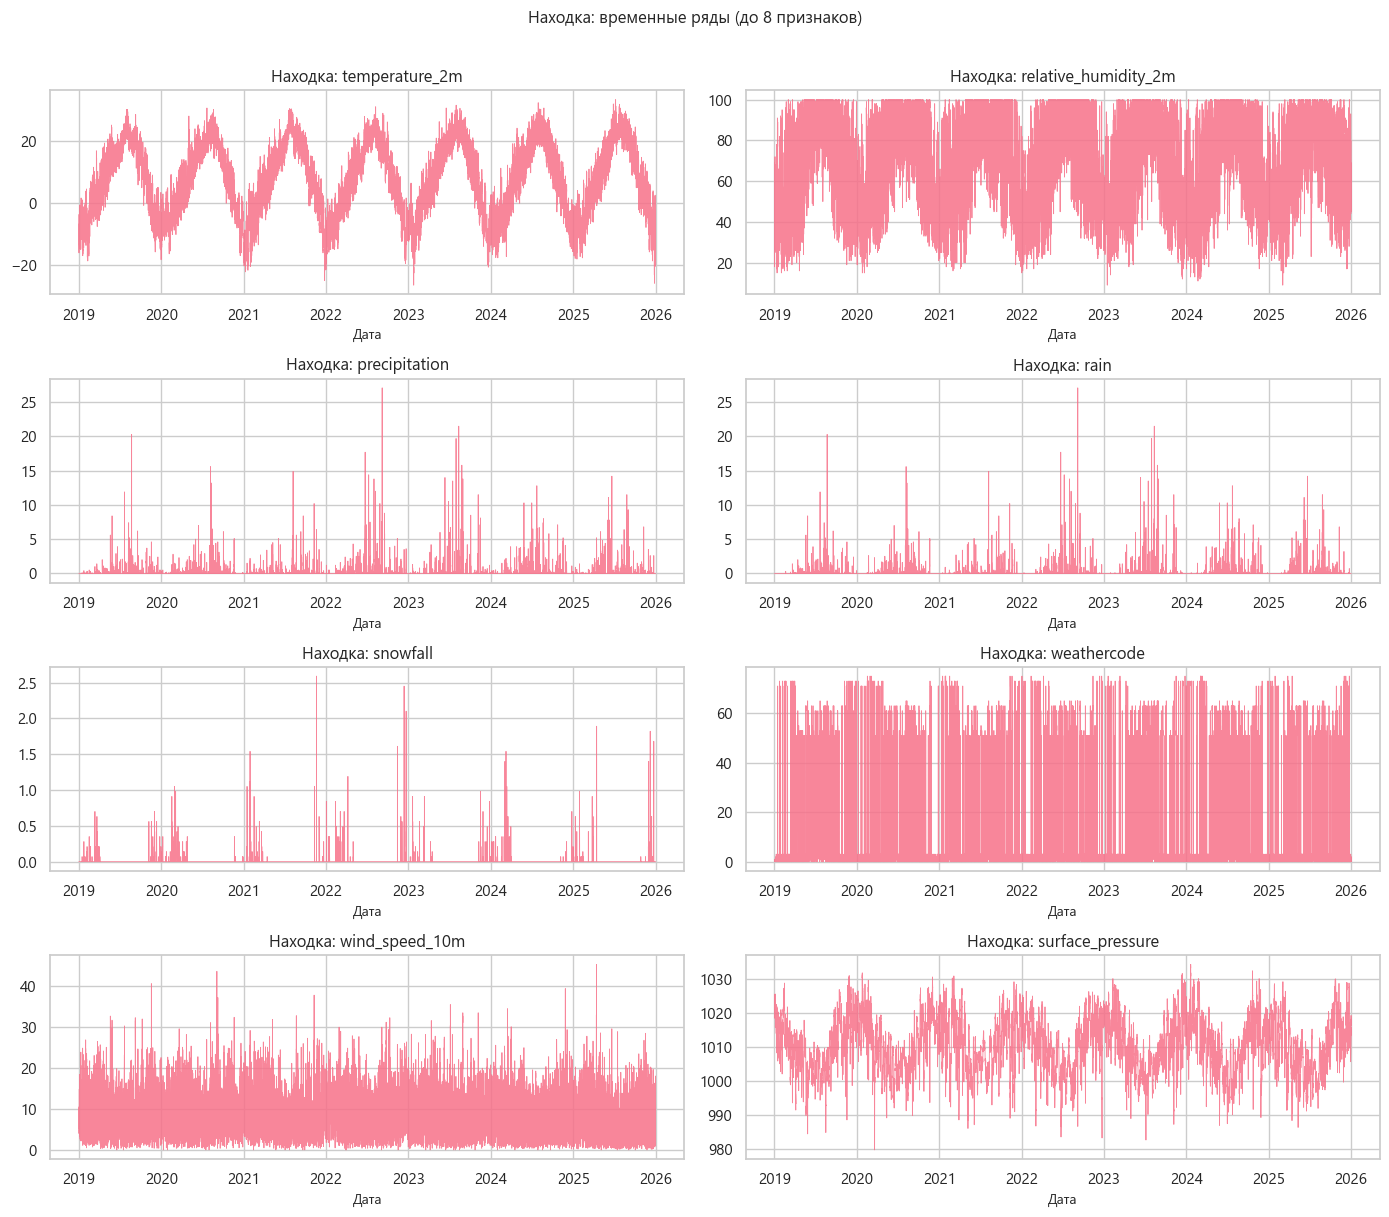

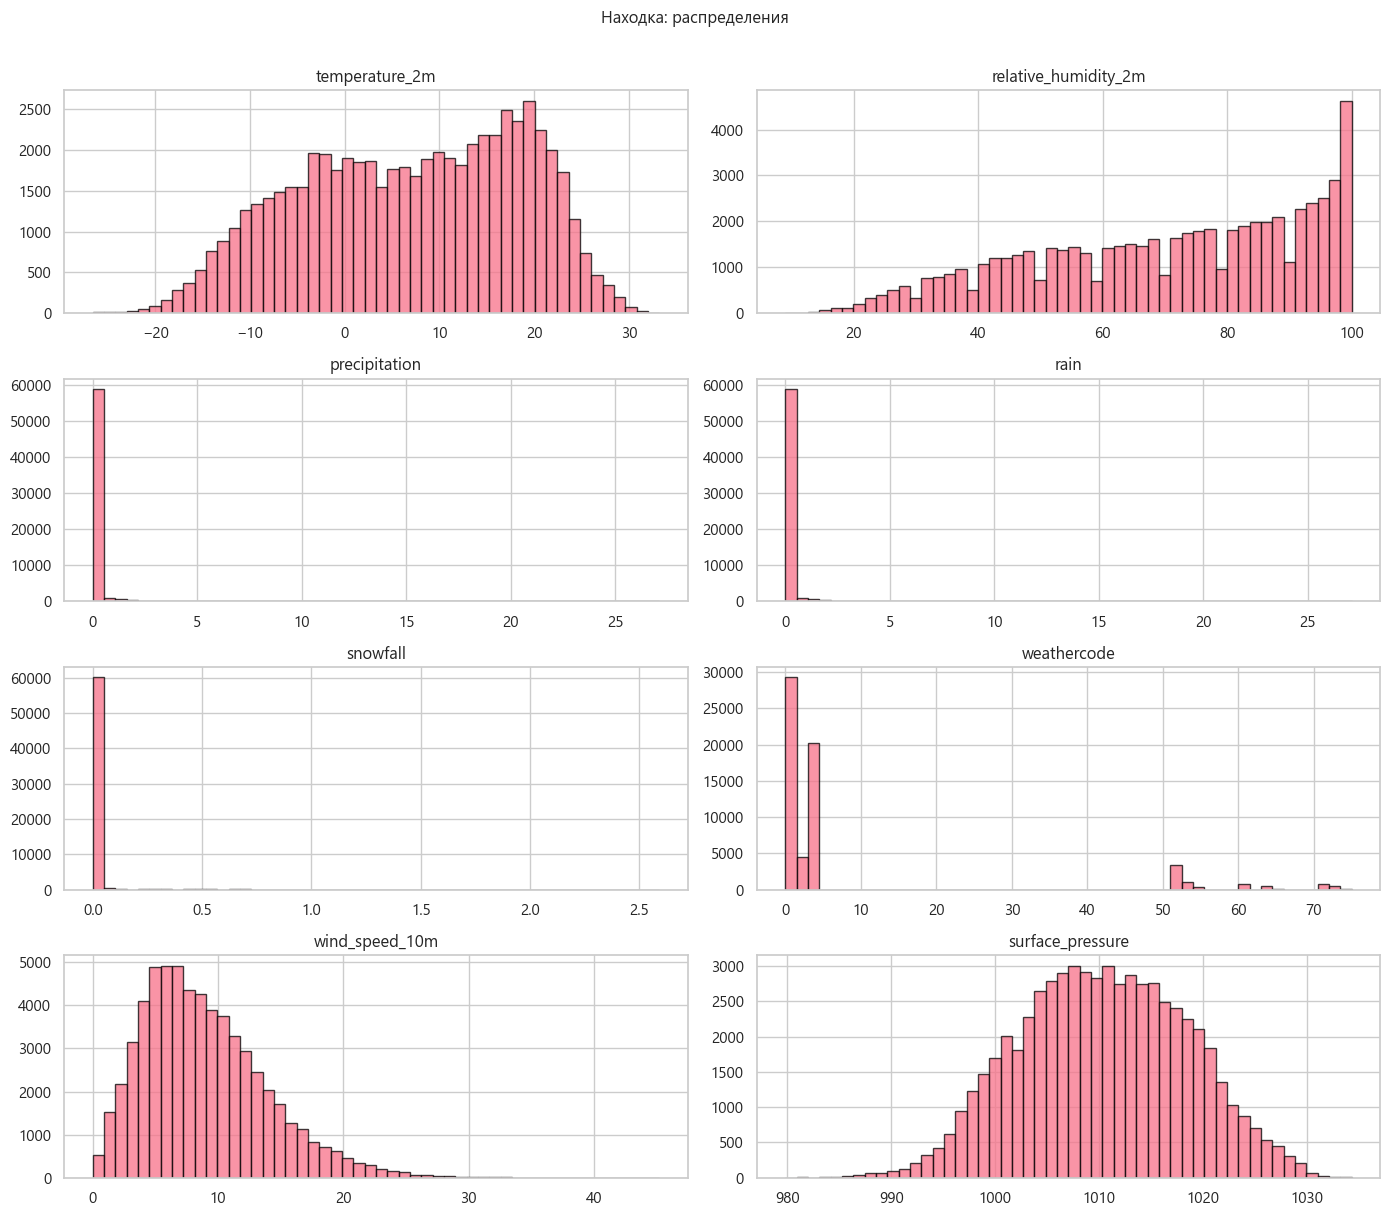

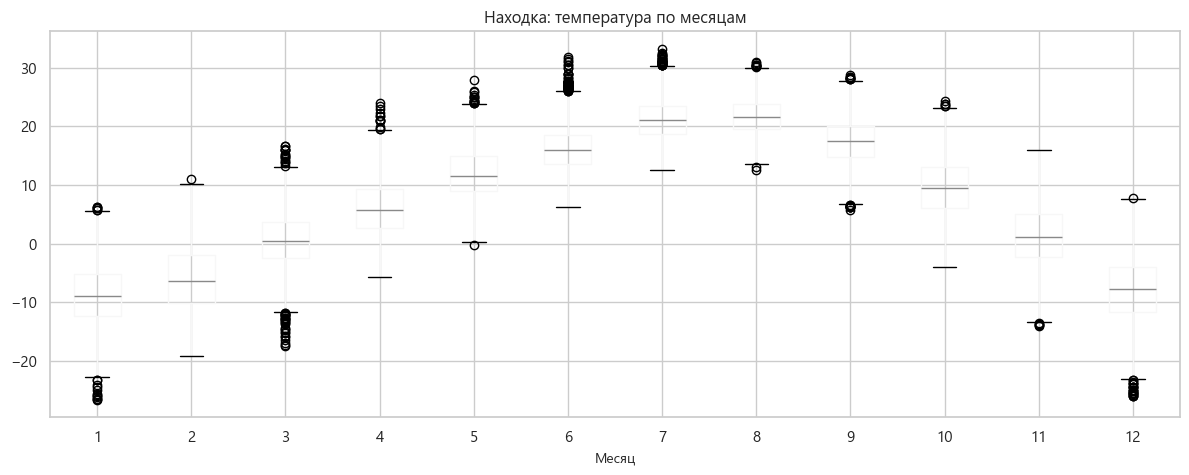

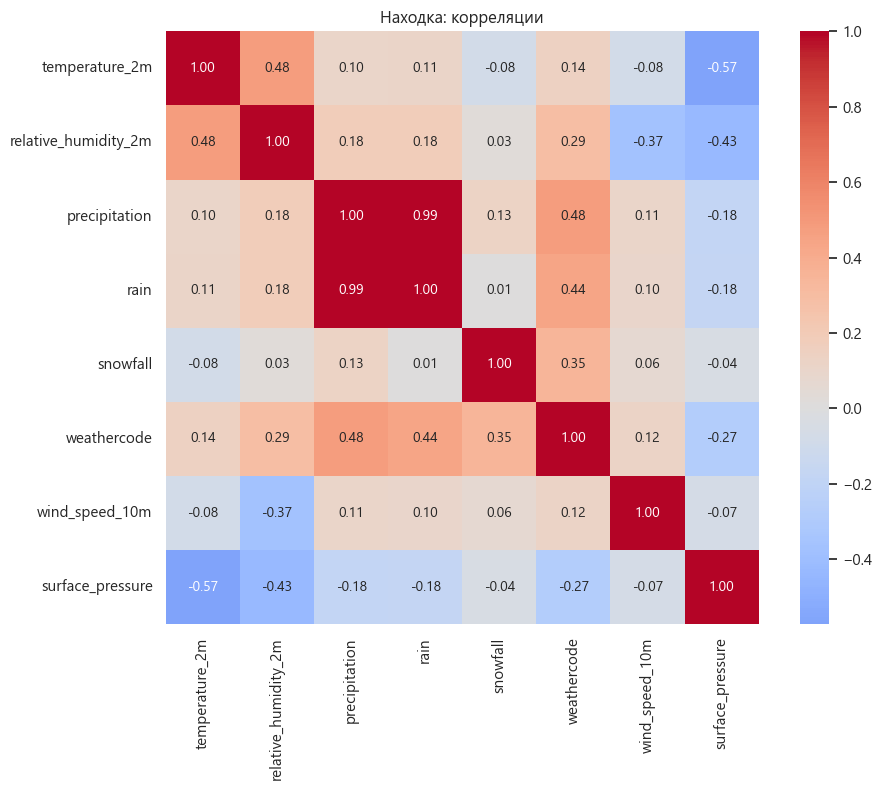

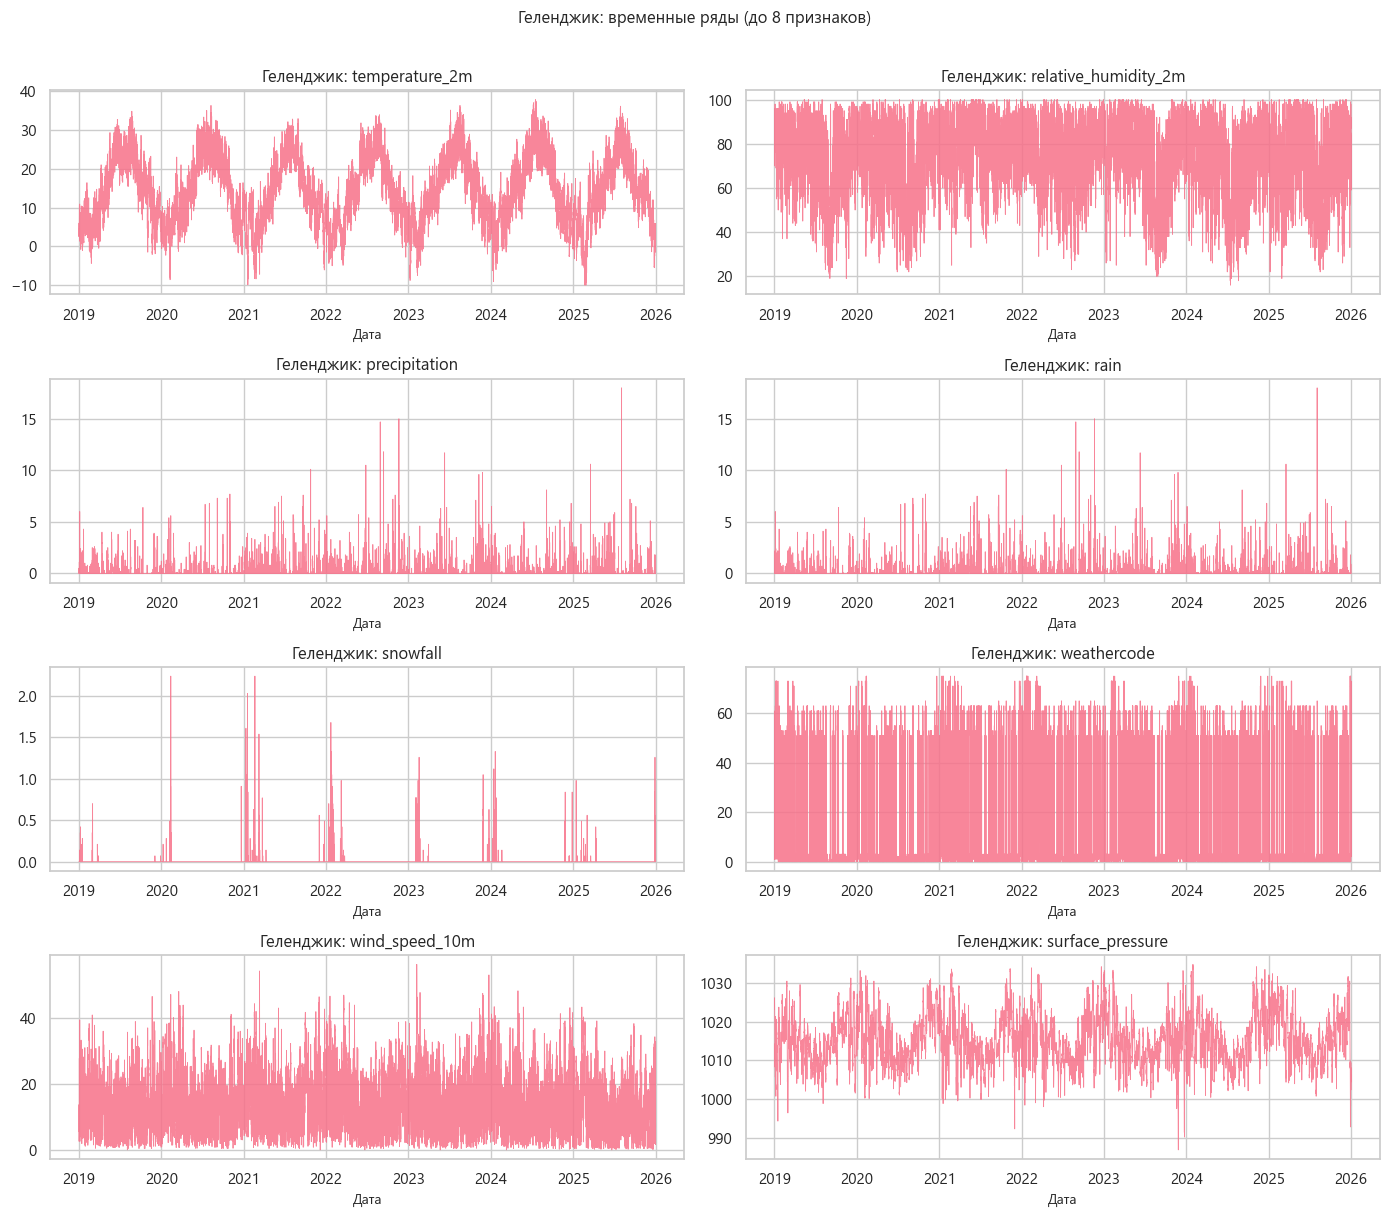

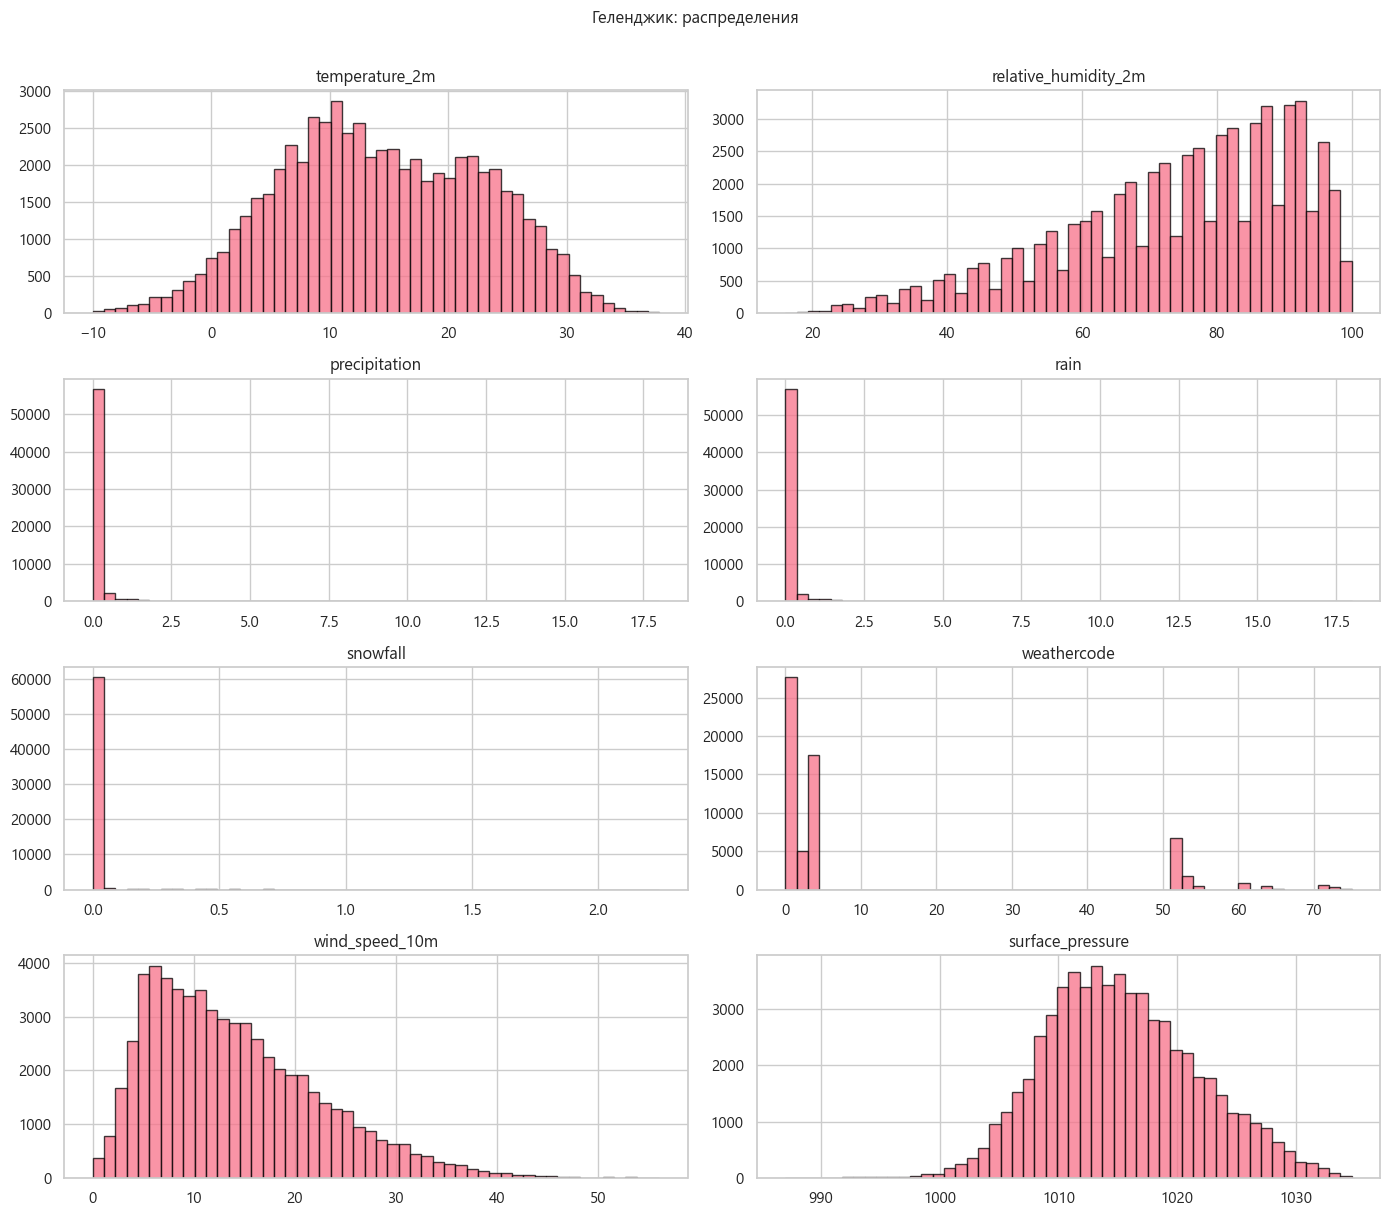

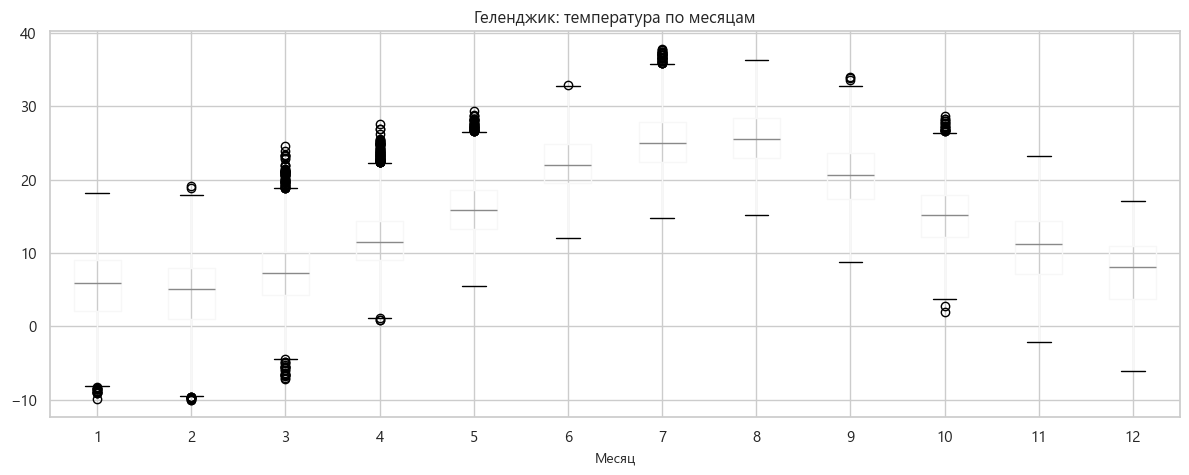

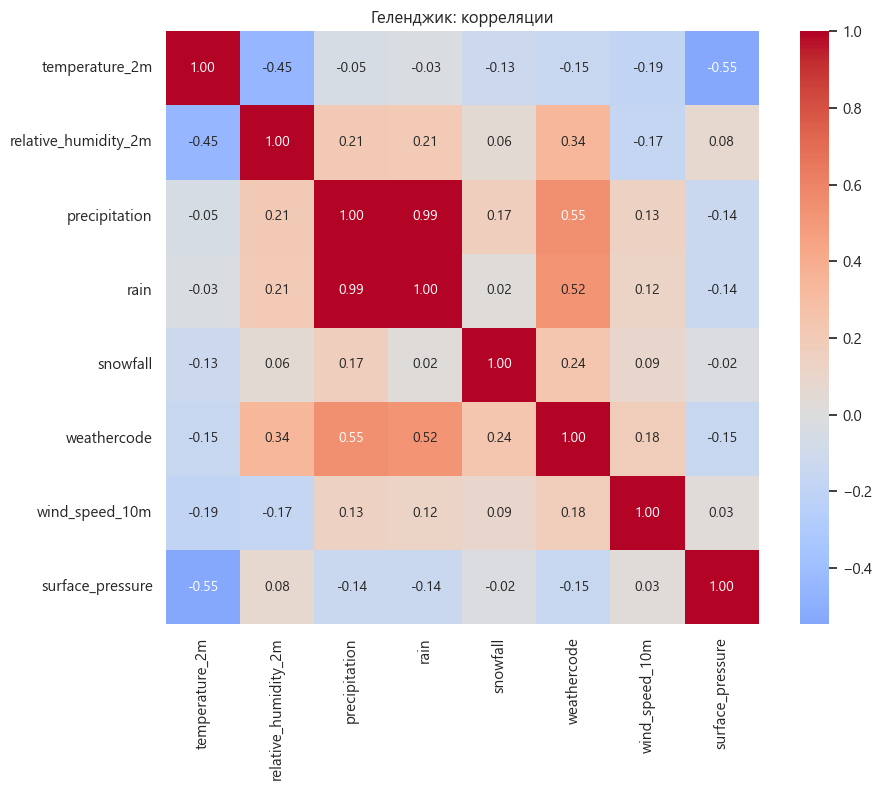

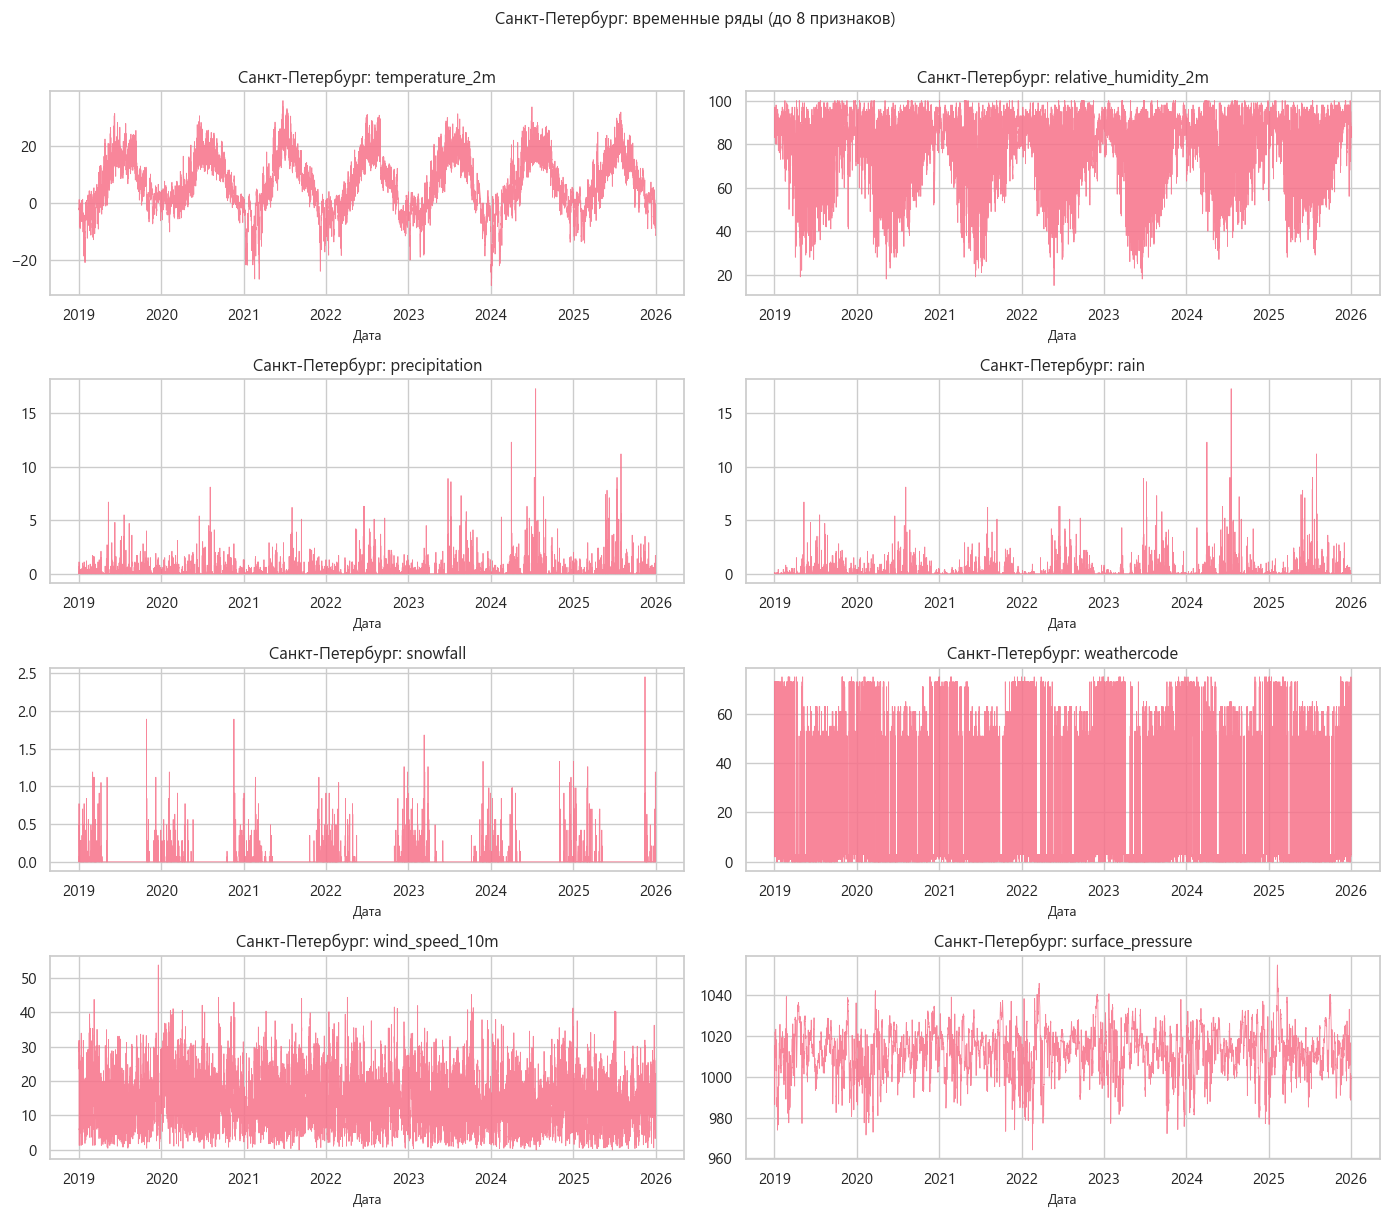

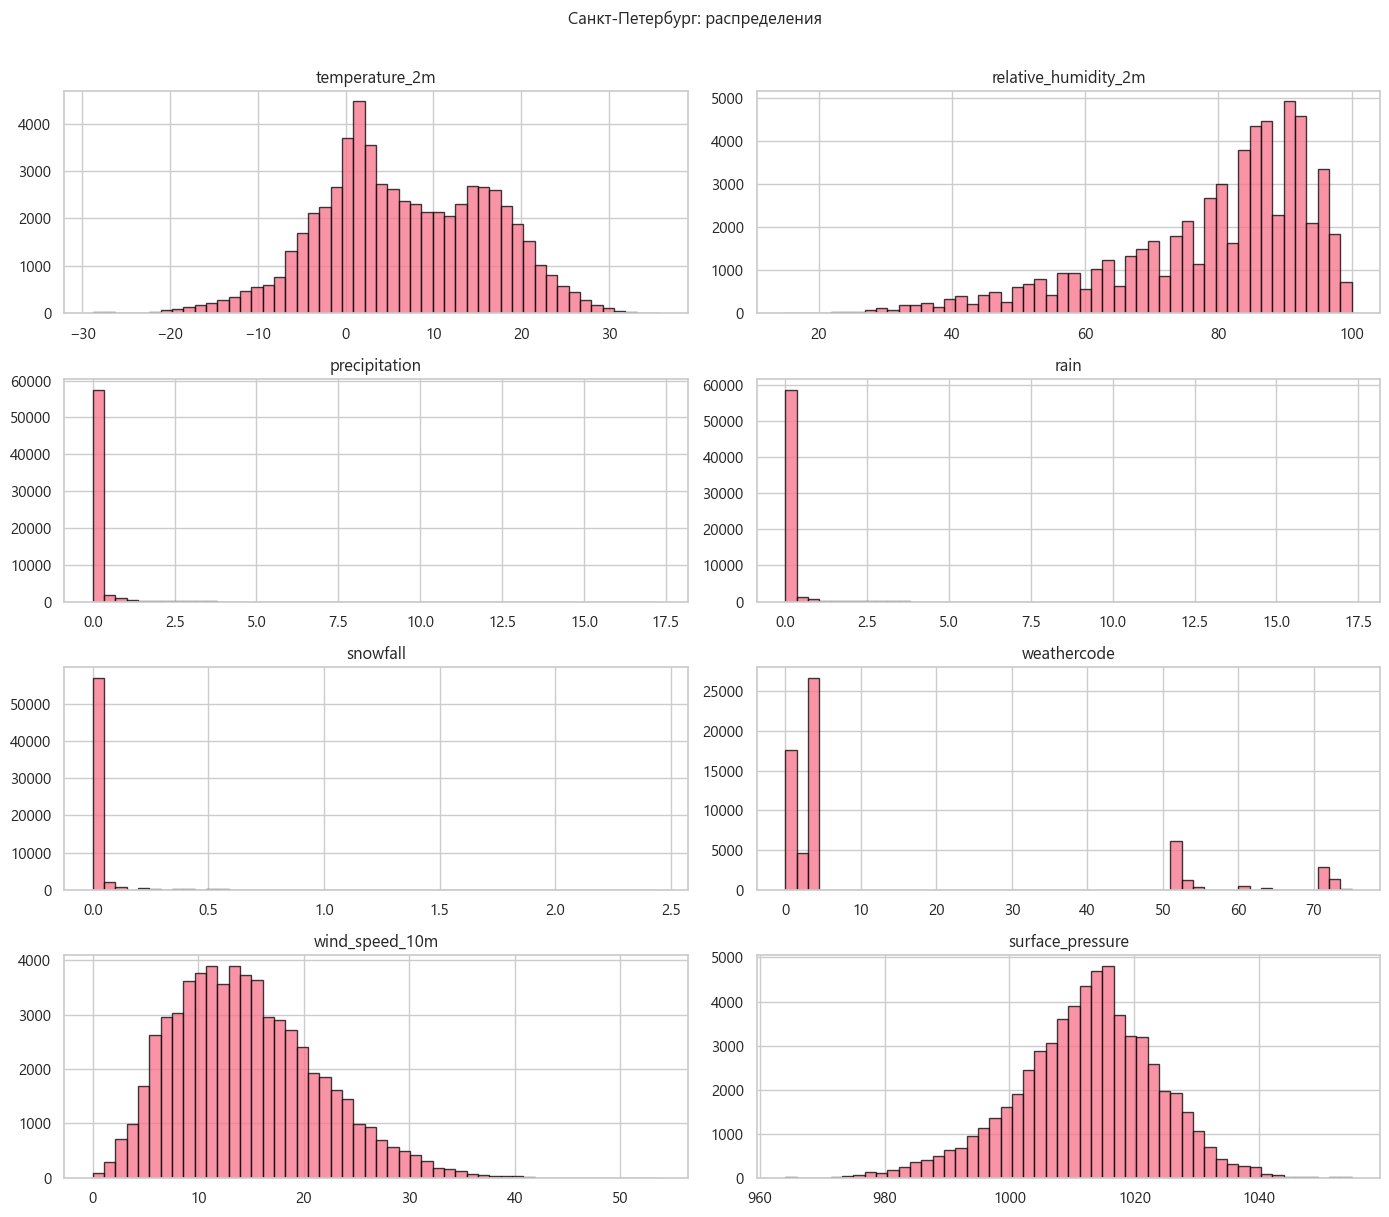

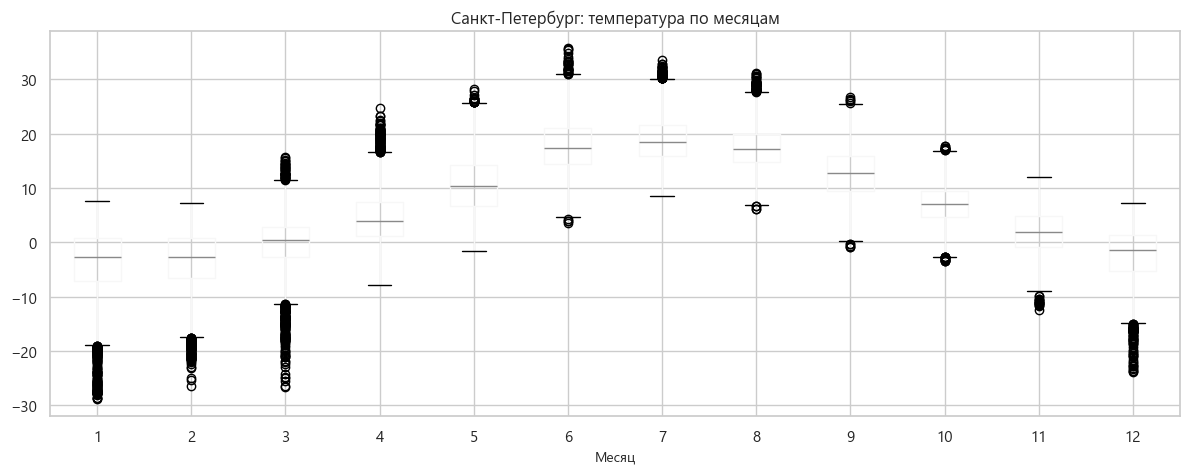

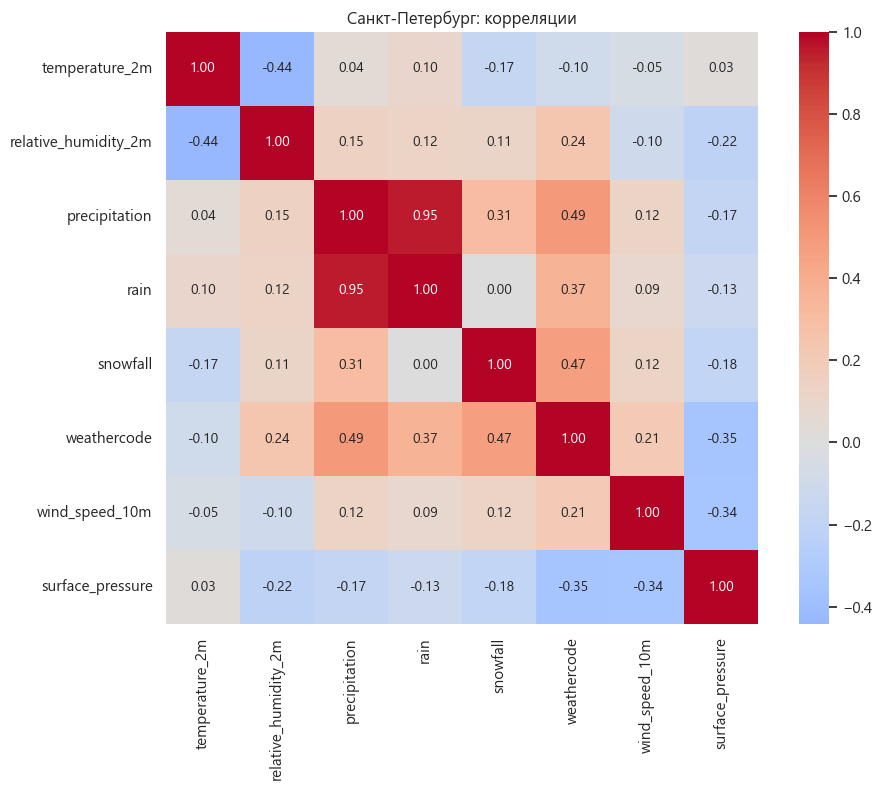

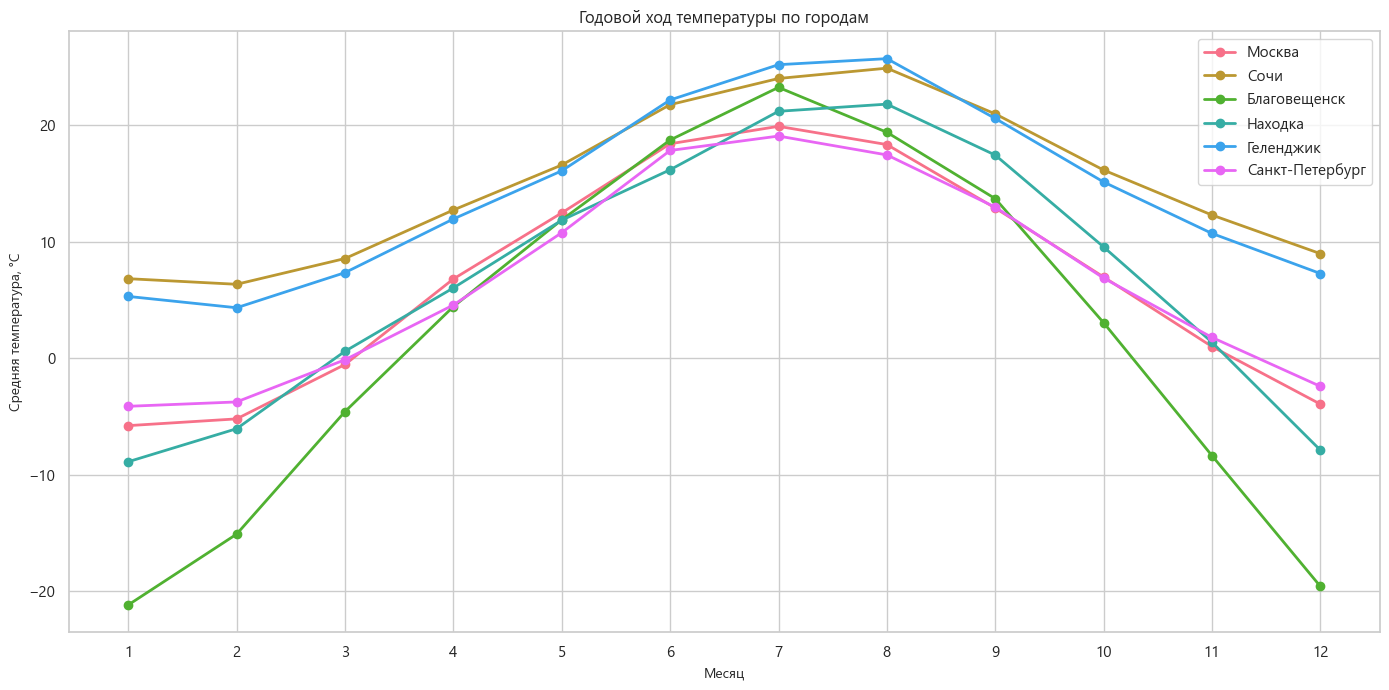

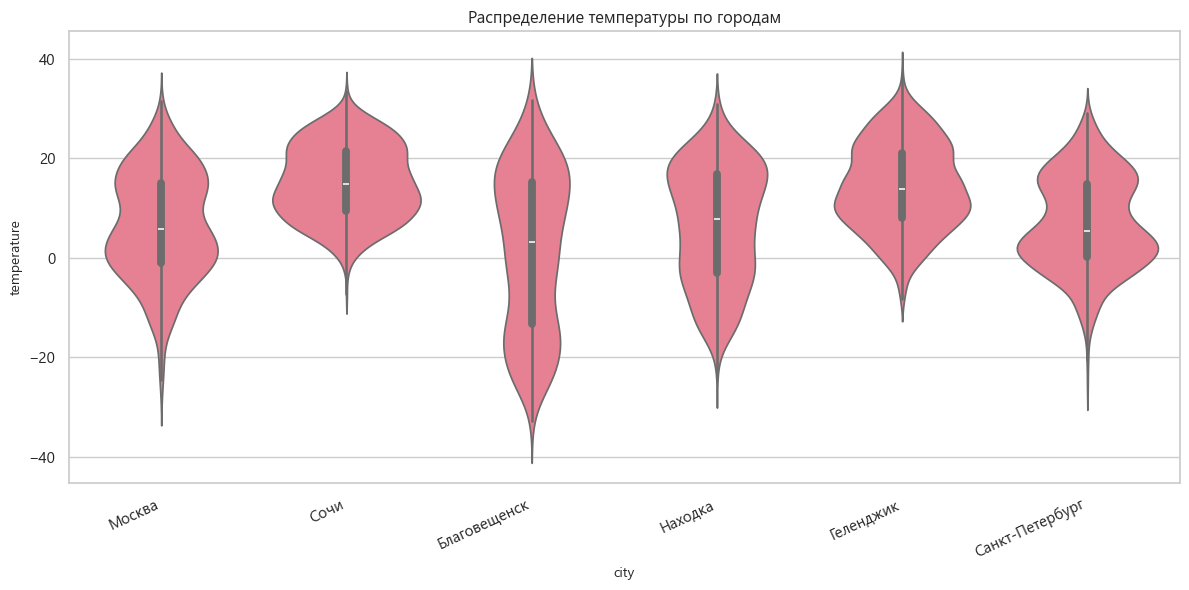

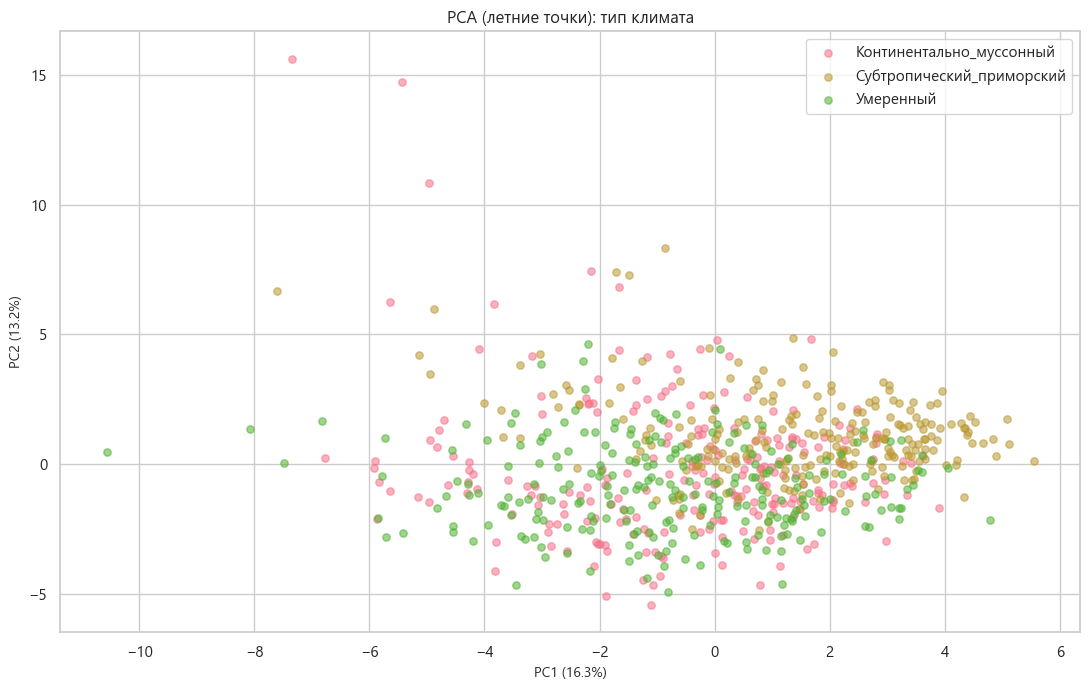

Графики: C:\Users\kholina\Desktop\Анализ\LAB_3\results\figures
Индекс: C:\Users\kholina\Desktop\Анализ\LAB_3\results\EDA_REPORT.md
ADF: C:\Users\kholina\Desktop\Анализ\LAB_3\results\eda_adf_summary.txt


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    from IPython import get_ipython as _get_ipython
    _ipy = _get_ipython()
    if _ipy is not None:
        _ipy.run_line_magic("matplotlib", "inline")
except Exception:
    pass

from src.config import DATA_DIR, RESULTS_DIR
from src.data_loader import load_or_demo
from src.eda_report import generate_eda_report

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

data = load_or_demo(DATA_DIR)
print("Города:", list(data.keys()))
fig_dir = generate_eda_report(data=data, results_dir=RESULTS_DIR)
print("Графики:", fig_dir)
print("Индекс:", RESULTS_DIR / "EDA_REPORT.md")
print("ADF:", RESULTS_DIR / "eda_adf_summary.txt")

## 2.2 Инжиниринг признаков

Формирование признаков для классификационного окна на примере одного города.


### Выводы по разделу 2.2 (инжиниринг признаков)

**Ширина окна и лаги.** Окно фиксированной длины (в коде классификации — 30 наблюдений ряда) задаёт «память» модели о недавней синоптике: в почасовых данных это порядка суток с лишним, то есть режим краткосрочной погоды, а не климатической нормы. Лаги переносят значения признаков на несколько шагов назад и позволяют учитывать инерцию процессов (температура, влажность, облачность). `window_stride > 1` уменьшает число пересекающихся окон, ускоряет обучение и снижает избыточную корреляцию между соседними примерами за счёт редкой выборки окон.

**Циклические признаки времени (sin/cos).** Календарные величины (час суток, день года) цикличны: 23:00 и 01:00 близки по смыслу, но не по числовому значению. Пара «sin/cos» задаёт непрерывную фазу на окружности и устраняет разрыв на границе суток/года, что улучшает работу линейных и древесных моделей без ручного биннинга.

**PCA и зоны.** Визуализация PCA по агрегированным статистикам окна (`results/figures/pca_zones_summer.png`, при генерации EDA-отчёта) показывает **частичное** разделение климатических зон в пространстве главных компонент; зоны со сходными сезонными профилями перекрываются, что согласуется с последующей путаницей классов в матрице ошибок.

In [2]:
import pandas as pd
from src.features import prepare_features_for_classification

city = next(iter(data.keys()))
df_demo = data[city].copy()
df_demo["timestamp"] = pd.to_datetime(df_demo["timestamp"])
df_demo = df_demo.sort_values("timestamp")
feat_df = prepare_features_for_classification(df_demo)
print(city, "число признаков:", feat_df.shape[1])
print(feat_df.columns[:25].tolist(), "...")

Москва число признаков: 41
['timestamp', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'hour', 'day_of_week', 'day_of_month', 'month', 'year', 'day_of_year', 'season', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos', 'temp_amplitude', 'precip_days_count', 'max_wind_speed', 'mean_temp', 'temp_std'] ...


## 2.3 Классификация типа климата

**Основная модель TSC:** `KNeighborsTimeSeriesClassifier` с метрикой **DTW** (`tslearn`). Модель сравнивает **целые многомерные окна** рядов и допускает несовпадение фаз по времени, что соответствует природе метеопаттернов и предпочтительнее классификации по одному моменту без учёта формы окна.

**Baseline:** `RandomForestClassifier` по вектору **агрегированных** статистик окна (не специализированный TSC; используется как ориентир качества на табличных признаках). Для данной постановки без серьёзной доработки слабы наивные модели, игнорирующие структуру окна, а также логистическая регрессия по «развёрнутому» окну без регуляризации и достаточного объёма данных — они хуже отражают форму ряда, чем DTW.

Задача усложняется **сезонным пересечением** режимов между городами разных зон, шумом и **многомерностью** окна.

В коде используется шаг выборки окон `WINDOW_STRIDE` (в ноутбуке — 7): он уменьшает число пересекающихся окон и время счёта; полный перебор без прореживания соответствует `WINDOW_STRIDE = 1`.

In [3]:
WINDOW_STRIDE = 7  # полная выборка окон: значение 1

from src.classify import train_classifiers

clf_report = train_classifiers(
    data,
    window_size=30,
    label_mode="zone",
    test_ratio=0.2,
    skip_knn=False,
    window_stride=WINDOW_STRIDE,
)

rf_bundle = clf_report["random_forest_agg"]
knn_info = clf_report.get("knn_dtw", {})
knn_model = knn_info.get("model")
print("DTW обучен:", knn_model is not None)
if knn_info.get("error"):
    print("Ошибка DTW:", knn_info["error"])

--- KNeighborsTimeSeries (DTW) ---
(ускорение демо: DTW fit на 800 из 42038 окон)
(DTW predict на подвыборке теста: 400)
Accuracy: 0.7825
                           precision    recall  f1-score   support

 Континентально_муссонный       0.73      0.82      0.77       141
Субтропический_приморский       0.80      0.91      0.85       134
                Умеренный       0.85      0.60      0.70       125

                 accuracy                           0.78       400
                macro avg       0.79      0.78      0.78       400
             weighted avg       0.79      0.78      0.78       400

--- RandomForest на статистиках окна ---
Размер выборки классификации: train=42038, test=10510
Accuracy: 0.8605
                           precision    recall  f1-score   support

 Континентально_муссонный       0.82      0.88      0.85      3503
Субтропический_приморский       0.90      0.93      0.92      3503
                Умеренный       0.86      0.77      0.81      3504

        

## 2.4 Оценка качества классификации


=== RandomForest (baseline), classification report ===
                           precision    recall  f1-score   support

 Континентально_муссонный       0.82      0.88      0.85      3503
Субтропический_приморский       0.90      0.93      0.92      3503
                Умеренный       0.86      0.77      0.81      3504

                 accuracy                           0.86     10510
                macro avg       0.86      0.86      0.86     10510
             weighted avg       0.86      0.86      0.86     10510

macro F1: 0.8594658433067117


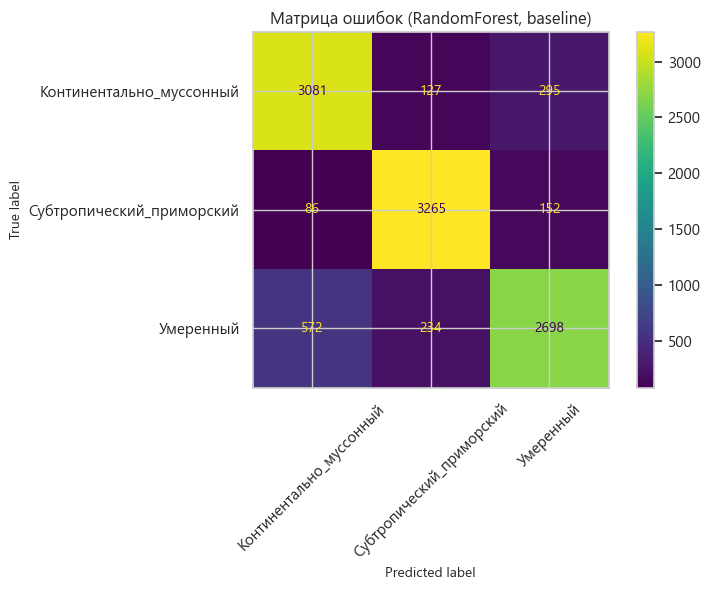

Сохранено: C:\Users\kholina\Desktop\Анализ\LAB_3\results\figures\confusion_matrix_rf.png
ROC-AUC macro (OvR), RF: 0.9602688141017812


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.preprocessing import LabelEncoder, label_binarize

rf = rf_bundle["model"]
y_test = rf_bundle["y_test"]
y_pred_rf = rf_bundle["y_pred"]
proba_rf = rf_bundle["y_proba"]

classes = rf.classes_
print("=== RandomForest (baseline), classification report ===")
print(classification_report(y_test, y_pred_rf, labels=classes, zero_division=0))

P, R, F1, sup = precision_recall_fscore_support(y_test, y_pred_rf, labels=classes, zero_division=0)
print("macro F1:", F1.mean())

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf, labels=classes), display_labels=classes).plot(ax=ax, xticks_rotation=45)
ax.set_title("Матрица ошибок (RandomForest, baseline)")
fig.tight_layout()
OUTCM = RESULTS_DIR / "figures" / "confusion_matrix_rf.png"
OUTCM.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTCM, dpi=120, bbox_inches="tight")
try:
    from IPython.display import display
    display(fig)
except Exception:
    plt.show()
plt.close(fig)
print("Сохранено:", OUTCM)

# ROC-AUC OvR (по вероятностям RF)
le = LabelEncoder().fit(classes)
y_te_bin = label_binarize(le.transform(y_test), classes=np.arange(len(classes)))
roc = roc_auc_score(y_te_bin, proba_rf, average="macro", multi_class="ovr")
print("ROC-AUC macro (OvR), RF:", roc)

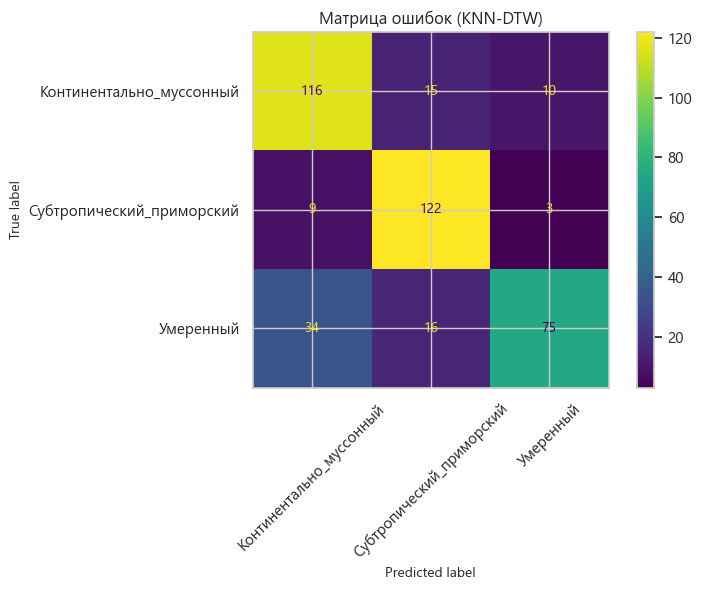

Сохранено: C:\Users\kholina\Desktop\Анализ\LAB_3\results\figures\confusion_matrix_dtw.png
                           precision    recall  f1-score   support

 Континентально_муссонный       0.73      0.82      0.77       141
Субтропический_приморский       0.80      0.91      0.85       134
                Умеренный       0.85      0.60      0.70       125

                 accuracy                           0.78       400
                macro avg       0.79      0.78      0.78       400
             weighted avg       0.79      0.78      0.78       400



In [5]:
# DTW: матрица ошибок на подвыборке теста (если модель есть)
if knn_model is not None and "y_test" in knn_info and "y_pred" in knn_info:
    yt = knn_info["y_test"]
    yp = knn_info["y_pred"]
    labels = sorted(np.unique(np.concatenate([yt, yp])))
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay(confusion_matrix(yt, yp, labels=labels), display_labels=labels).plot(ax=ax, xticks_rotation=45)
    ax.set_title("Матрица ошибок (KNN-DTW)")
    fig.tight_layout()
    p = RESULTS_DIR / "figures" / "confusion_matrix_dtw.png"
    fig.savefig(p, dpi=120, bbox_inches="tight")
    try:
        from IPython.display import display
        display(fig)
    except Exception:
        plt.show()
    plt.close(fig)
    print("Сохранено:", p)
    print(classification_report(yt, yp, labels=labels, zero_division=0))
else:
    print("DTW-матрица пропущена (модель не обучена или нет предсказаний).")

### Итог по разделам 2.3–2.4 (классификация и её оценка)

Основной классификатор временных рядов в работе — **KNeighborsTimeSeriesClassifier с метрикой DTW** (`tslearn`). Для сравнения используется **RandomForestClassifier** по агрегированным статистикам окна (baseline на табличных признаках).

Получены следующие показатели качества на тестовой выборке окон: **KNN-DTW — accuracy 0.7825**, расчёт выполнен на **подвыборке из 400** тестовых окон (снижение вычислительной нагрузки DTW); macro/weighted **F1** для этой подвыборки порядка **0.78**. **RandomForest — accuracy 0.8605** на **полном** тестовом наборе окон.

Выбор DTW методологически согласован с постановкой TSC: метрика допускает сопоставление близких погодных паттернов при небольших временных сдвигах, что важно для почасовых метеоданных.

Наиболее сложной для распознавания по KNN-DTW оказалась зона **«Умеренный»** (более низкий recall относительно других зон), что согласуется с пересечением температурных и осадочных режимов в межсезонье (в частности, профили Москвы и Санкт-Петербурга). Для RandomForest также отмечается более низкий recall класса «Умеренный» по сравнению с субтропическим.

В дальнейшем пайплайне (раздел 2.7) основным классификатором режима используется обученная модель **KNN-DTW**; RandomForest выполняет роль baseline при интерпретации разрыва качества. **Сравнение accuracy между моделями не является строго симметричным:** оценка для DTW получена на **подвыборке** тестовых окон, для RF — на **полном** тесте; это следует учитывать при интерпретации численных результатов.

## 2.5 Прогноз температуры (горизонт H=30 шагов ряда)

Используются **почасовые** ряды Open-Meteo. Горизонт **H = 30 шагов** соответствует **30 часам** вперёд по времени индекса ряда, а не **30 календарным суткам** и не последовательности из тридцати суточных прогнозов. Для постановки с дискретностью «один день» и целевым горизонтом **30 суток** требуется **ресемплинг** ряда до суточной частоты и/или **multi-step** схема прогноза по дням.


### Постановка задачи прогноза и календарный горизонт

При формулировке задания в терминах «прогноз на каждый день следующего месяца» настоящая реализация задаёт **одну целевую величину** — температуру в момент **t + H** с **H = 30** в **шагах почасового ряда** — для каждого обучающего наблюдения с достаточной историей признаков.

Путь к постановке «30 календарных дней вперёд» включает: (1) ресемплинг исходного ряда до суточной частоты и выбор **H = 30** в единицах **суток**; либо (2) multi-step модель (direct или recursive), формирующую последовательность из тридцати суточных прогнозов.

Метрики раздела 2.6 относятся к качеству прогноза на **фиксированном горизонте** **t + H** в исходной **почасовой** дискретизации.

In [6]:
from src.forecast import train_all_cities

forecast_bundles = train_all_cities(data, horizon=30, use_prophet=False)

for city, b in forecast_bundles.items():
    print(city, b["metrics"])


=== Москва: train=43794 val=8784 test=8730 ===

=== Сочи: train=43794 val=8784 test=8730 ===

=== Благовещенск: train=43794 val=8784 test=8730 ===

=== Находка: train=43794 val=8784 test=8730 ===

=== Геленджик: train=43794 val=8784 test=8730 ===

=== Санкт-Петербург: train=43794 val=8784 test=8730 ===
Москва {'LightGBM': {'mae': 2.5372525729161137, 'rmse': 3.3035248818537744, 'mape': 99.60829601226192}, 'RandomForest': {'mae': 2.5830015153597365, 'rmse': 3.4271201250550476, 'mape': 108.21198992997736}, 'Prophet': {'skipped': True}}
Сочи {'LightGBM': {'mae': 2.1781480786255227, 'rmse': 2.9027566350011154, 'mape': 55.162274289640415}, 'RandomForest': {'mae': 2.2862339303288213, 'rmse': 3.062422501972338, 'mape': 61.576601655148814}, 'Prophet': {'skipped': True}}
Благовещенск {'LightGBM': {'mae': 2.692886111726893, 'rmse': 3.5794407437002738, 'mape': 58.6515544615345}, 'RandomForest': {'mae': 2.80614419154008, 'rmse': 3.6981675934242926, 'mape': 63.124453805611246}, 'Prophet': {'skipped

### Итог по разделу 2.5 (построение моделей прогнозирования)

**Выборка для прогноза.** Признаки формируются из метеопараметров, **лагов**, **скользящих статистик**, календарных и **циклических** признаков времени (функция `prepare_forecasting_frame`). Если задание задаёт окно «последние **N календарных дней**» и цель «температура через **30 суток**», то в **почасовой** постановке используется эквивалент в шагах ряда; в данной работе целевая переменная — `shift(-30)` при почасовом индексе, т.е. **30 часов** вперёд, а не 30 суток и не набор из тридцати посуточных прогнозов. Переход к суточному горизонту **30 дней** описан в предыдущем абзаце (ресемплинг / multi-step).

**Разбиение по годам:** обучение — **2019–2023**, валидация — **2024**, тест — **2025** (реализация в `train_city_forecasters`). Валидационный год выделен в коде и может использоваться для подбора гиперпараметров и ранней остановки.

**Модели по городам и климатическим зонам.** На **каждый город** отдельно обучены регрессоры **LightGBM** и **RandomForest**. Модель **Prophet** поддерживается опционально и в данном ноутбуке не активируется из соображений времени счёта на длинных почасовых рядах. Различие климатических зон проявляется в распределениях и динамике рядов; **локальное** обучение на данных города повышает адекватность по сравнению с одной общей моделью на все точки. В едином пайплайне (раздел 2.7) после классификации зоны подключается модель **представительского города** зоны — это реализует идею **разных оптимальных настроек прогноза для разных климатических режимов** при единой архитектуре семейства моделей (градиентный бустинг и случайный лес).

**Модели, малопригодные для горизонта порядка месяца без доработки постановки:** наивные методы без явной сезонности; перенос «сегодняшнего» значения на много шагов вперёд; линейная регрессия без циклических признаков и без достаточной лаговой структуры; конфигурации с экстремально короткой памятью без учёта годового цикла.

На тесте **2025** для большинства городов **LightGBM** даёт **меньшие MAE и RMSE**, чем **RandomForest**. Показатель **MAPE** при температурах, близких к нулю, становится неустойчивым; основными метриками для сопоставления городов считаются **MAE** и **RMSE** (а также **WAPE** в разделе 2.6).

В результате раздела 2.5 получен набор **локальных** регрессионных моделей прогноза температуры на горизонт **t + H** в шагах почасового ряда; раздел 2.6 содержит численную и статистическую оценку качества.

## 2.6 Оценка качества прогнозирования

Точечные метрики, метрика направления, графики «факт — прогноз», диагностика остатков и box-plot по городам.


,city,model,wape,dir_acc,mae,rmse,mape
0,Москва,LightGBM,25.825825,0.630656,2.537253,3.303525,99.608296
1,Москва,RandomForest,26.291488,0.607859,2.583002,3.427120,108.211990
2,Сочи,LightGBM,14.906811,0.644289,2.178148,2.902757,55.162274
3,Сочи,RandomForest,15.646529,0.615191,2.286234,3.062423,61.576602
4,Благовещенск,LightGBM,18.235527,0.709474,2.692886,3.579441,58.651554
5,Благовещенск,RandomForest,19.002482,0.694810,2.806144,3.698168,63.124454
6,Находка,LightGBM,20.046357,0.699393,2.370405,3.129613,90.653197
7,Находка,RandomForest,20.831191,0.676710,2.463209,3.252138,96.684299
8,Геленджик,LightGBM,16.920320,0.640852,2.416150,3.165460,79.889065
9,Геленджик,RandomForest,18.059864,0.625616,2.578872,3.418939,87.325426


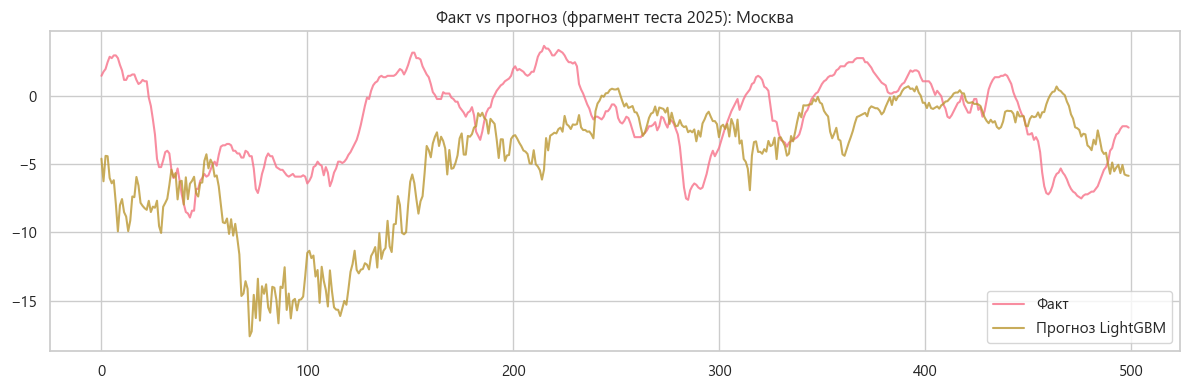

Сохранено: C:\Users\kholina\Desktop\Анализ\LAB_3\results\figures\forecast_fact_vs_pred_moscow.png


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def wape(y_true, y_pred):
    denom = np.sum(np.abs(y_true))
    if denom == 0:
        return float("nan")
    return float(np.sum(np.abs(y_true - y_pred)) / denom * 100)

def direction_accuracy(y_true, y_pred):
    if len(y_true) < 2:
        return float("nan")
    return float(np.mean(np.sign(np.diff(y_true)) == np.sign(np.diff(y_pred))))

city_plot = next(iter(forecast_bundles.keys()))

metrics_rows = []
for cname, fb in forecast_bundles.items():
    df_t = fb["inference_tail_df"]
    if "year" not in df_t.columns:
        continue
    test_df = df_t[df_t["year"] == 2025]
    if len(test_df) == 0:
        continue
    y_true = test_df["target"].values
    cols = fb["feature_cols"]
    X_te = test_df[cols].values
    for mkey in ("LightGBM", "RandomForest"):
        if mkey not in fb["models"]:
            continue
        pred = fb["models"][mkey].predict(X_te)
        row = {
            "city": cname,
            "model": mkey,
            "wape": wape(y_true, pred),
            "dir_acc": direction_accuracy(y_true, pred),
        }
        if mkey in fb["metrics"] and isinstance(fb["metrics"][mkey], dict):
            row.update({k: fb["metrics"][mkey][k] for k in ("mae", "rmse", "mape") if k in fb["metrics"][mkey]})
        metrics_rows.append(row)

met_df = pd.DataFrame(metrics_rows)
try:
    display(met_df)
except NameError:
    print(met_df.to_string(index=False))

# График для одного города (LightGBM)
fb = forecast_bundles[city_plot]
test_df = fb["inference_tail_df"][fb["inference_tail_df"]["year"] == 2025]
if len(test_df) > 0 and "LightGBM" in fb["models"]:
    y_true = test_df["target"].values
    pred = fb["models"]["LightGBM"].predict(test_df[fb["feature_cols"]].values)
    n = min(500, len(y_true))
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(y_true[:n], label="Факт", alpha=0.8)
    ax.plot(pred[:n], label="Прогноз LightGBM", alpha=0.8)
    ax.set_title(f"Факт vs прогноз (фрагмент теста 2025): {city_plot}")
    ax.legend()
    fig.tight_layout()
    from src.config import CITY_FILE_SLUG
    slug = CITY_FILE_SLUG.get(city_plot, city_plot)
    gp = RESULTS_DIR / "figures" / f"forecast_fact_vs_pred_{slug}.png"
    gp.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(gp, dpi=120, bbox_inches="tight")
    try:
        from IPython.display import display
        display(fig)
    except Exception:
        plt.show()
    plt.close(fig)
    print("Сохранено:", gp)

### Диагностика остатков и box-plot

Остатки определяются как \(e_t = y_t - \hat{y}_t\) на **тестовом периоде 2025 г.**

**Критерий Шапиро–Уилка** проверяет гипотезу нормального распределения остатков. При длине ряда более 5000 наблюдений применяется **случайная подвыборка** объёма 5000 (фиксированное зерно генератора), что ослабляет эффект сверхвысокой мощности теста на очень больших выборках.

**Статистика Льюнга–Бокса** оценивает автокорреляцию остатков; порядок лага задаётся в коде (максимум 15 при достаточной длине ряда).

**Тест Уайта** выполняется для проверки гетероскедастичности во вспомогательной постановке: остатки рассматриваются совместно с регрессорами «константа + прогноз \(\hat{y}\)».

**Box-plot** иллюстрирует распределение остатков по городам для моделей **LightGBM** и **RandomForest**.

,city,model,n_residuals,shapiro_stat,shapiro_pvalue,shapiro_note,ljungbox_lag,ljungbox_stat,ljungbox_pvalue,white_lm_stat,white_pvalue
0,Москва,LightGBM,8730,0.992972,5.302118e-15,подвыборка n=5000,15,70924.865802,0.0,1073.927501,6.303854e-234
1,Москва,RandomForest,8730,0.987304,8.214342e-21,подвыборка n=5000,15,67836.506282,0.0,1214.336886,2.042188e-264
2,Сочи,LightGBM,8730,0.981467,4.521877e-25,подвыборка n=5000,15,51341.721631,0.0,353.662678,1.596340e-77
3,Сочи,RandomForest,8730,0.980102,6.426385e-26,подвыборка n=5000,15,47237.898670,0.0,327.150026,9.125876e-72
4,Благовещенск,LightGBM,8730,0.989833,1.651462e-18,подвыборка n=5000,15,66748.519744,0.0,357.012854,2.989811e-78
5,Благовещенск,RandomForest,8730,0.992899,4.281915e-15,подвыборка n=5000,15,63352.522246,0.0,344.942504,1.249358e-75
6,Находка,LightGBM,8730,0.991482,8.892337e-17,подвыборка n=5000,15,56805.271146,0.0,869.740199,1.375041e-189
7,Находка,RandomForest,8730,0.989968,2.250819e-18,подвыборка n=5000,15,53513.258999,0.0,915.597747,1.515219e-199
8,Геленджик,LightGBM,8730,0.981324,3.670949e-25,подвыборка n=5000,15,61891.954311,0.0,639.815280,1.163797e-139
9,Геленджик,RandomForest,8730,0.973645,2.042462e-29,подвыборка n=5000,15,63294.389414,0.0,624.987577,1.930510e-136


Интерпретация: shapiro_pvalue < 0.05 — отклонение от нормальности; ljungbox_pvalue < 0.05 — значимая автокорреляция остатков; white_pvalue < 0.05 — признаки гетероскедастичности.


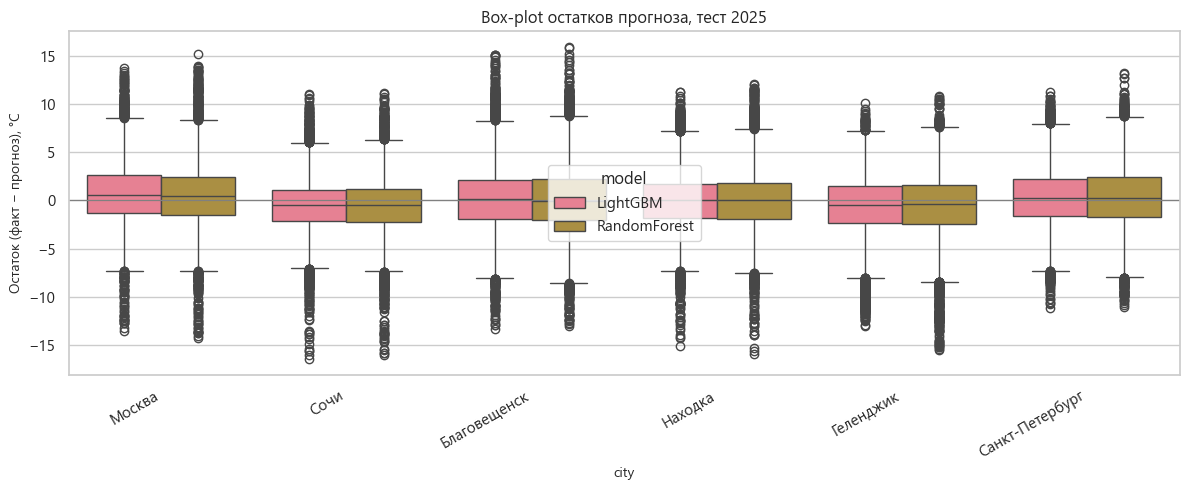

Сохранено: C:\Users\kholina\Desktop\Анализ\LAB_3\results\figures\forecast_residuals_boxplot_by_city.png


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox, het_white

SHAPIRO_MAX_N = 5000
LJUNG_LAGS = 15


def forecast_residual_tests(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    resid = y_true - y_pred
    n = len(resid)
    out: dict = {"n_residuals": n}
    if n < 8:
        out["note"] = "мало точек для тестов"
        return out

    rs = resid
    note_sh = "полная выборка"
    if n > SHAPIRO_MAX_N:
        rng = np.random.default_rng(42)
        rs = rng.choice(resid, size=SHAPIRO_MAX_N, replace=False)
        note_sh = f"подвыборка n={SHAPIRO_MAX_N}"
    sh_stat, sh_p = stats.shapiro(rs)
    out["shapiro_stat"] = float(sh_stat)
    out["shapiro_pvalue"] = float(sh_p)
    out["shapiro_note"] = note_sh

    maxlag = min(LJUNG_LAGS, n - 1)
    if maxlag >= 1:
        lb = acorr_ljungbox(resid, lags=[maxlag], model_df=0, return_df=True)
        out["ljungbox_lag"] = int(maxlag)
        out["ljungbox_stat"] = float(lb["lb_stat"].iloc[-1])
        out["ljungbox_pvalue"] = float(lb["lb_pvalue"].iloc[-1])

    exog = np.column_stack([np.ones(n), y_pred])
    try:
        lm, lm_p, _, f_p = het_white(resid, exog)
        out["white_lm_stat"] = float(lm)
        out["white_pvalue"] = float(lm_p)
    except Exception as exc:
        out["white_pvalue"] = float("nan")
        out["white_error"] = str(exc)

    return out


diag_rows = []
error_long = []

for cname, fb in forecast_bundles.items():
    df_t = fb["inference_tail_df"]
    if "year" not in df_t.columns:
        continue
    test_df = df_t[df_t["year"] == 2025]
    if len(test_df) < 20:
        continue
    y_true = test_df["target"].values
    X_te = test_df[fb["feature_cols"]].values

    for mkey in ("LightGBM", "RandomForest"):
        if mkey not in fb["models"]:
            continue
        pred = fb["models"][mkey].predict(X_te)
        resid = (y_true.astype(float) - pred.astype(float)).ravel()
        d = forecast_residual_tests(y_true, pred)
        diag_rows.append({"city": cname, "model": mkey, **d})
        for e in resid:
            error_long.append({"city": cname, "model": mkey, "error": float(e)})

diag_df = pd.DataFrame(diag_rows)
try:
    display(diag_df)
except NameError:
    print(diag_df.to_string(index=False))

print("Интерпретация: shapiro_pvalue < 0.05 — отклонение от нормальности; ljungbox_pvalue < 0.05 — значимая автокорреляция остатков; white_pvalue < 0.05 — признаки гетероскедастичности.")

if error_long:
    err_df = pd.DataFrame(error_long)
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.boxplot(data=err_df, x="city", y="error", hue="model", ax=ax)
    ax.tick_params(axis="x", rotation=30)
    for _lbl in ax.get_xticklabels():
        _lbl.set_ha("right")
    ax.axhline(0.0, color="gray", linewidth=0.9)
    ax.set_ylabel("Остаток (факт − прогноз), °C")
    ax.set_title("Box-plot остатков прогноза, тест 2025")
    fig.tight_layout()
    bp_path = RESULTS_DIR / "figures" / "forecast_residuals_boxplot_by_city.png"
    bp_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(bp_path, dpi=120, bbox_inches="tight")
    try:
        from IPython.display import display
        display(fig)
    except Exception:
        plt.show()
    plt.close(fig)
    print("Сохранено:", bp_path)

### Итог по разделу 2.6 (оценка качества прогнозирования)

На тестовой части данных (**2025 г.**) для каждого города вычислены **MAE, RMSE, MAPE** и **WAPE**, а также доля верных знаков приращений температуры (**точность направления**, `dir_acc`) для моделей **LightGBM** и **RandomForest**. Сводная таблица приведена в выводе соответствующей ячейки. По полученным результатам **LightGBM** даёт **меньшие** средние абсолютные и квадратичные ошибки почти по всем городам. Показатель **MAPE** при значениях температуры около нуля интерпретируется осторожно; для сравнения качества между городами используются **MAE, RMSE** и **WAPE**.

Для остатков \(y - \hat{y}\) на том же тесте выполнены тесты **Шапиро–Уилка**, **Льюнга–Бокса** и **Уайта** (значения статистик и p-value — в таблице над этим текстом). При **уровне значимости 0.05**: малое p-value у Шапиро–Уилка свидетельствует об отклонении распределения остатков от нормального; малое p-value у Льюнга–Бокса — о наличии автокорреляции остатков; малое p-value у Уайта — о гетероскедастичности в использованной вспомогательной постановке.

Построены линейные графики **наблюдаемая температура — прогноз** на фрагменте теста и **box-plot** остатков по городам с разбиением по моделям; последний сохранён в файле `results/figures/forecast_residuals_boxplot_by_city.png`.

Все метрики и диагностика остатков относятся к прогнозу на **фиксированном горизонте** **t + H** при **H = 30** шагах **почасового** ряда (**30 часов**), а не к последовательности из тридцати суточных прогнозов без перехода к суточной дискретизации.

## 2.7 Интеграция двух этапов


In [9]:
from src.pipeline import WeatherForecastingPipeline
from src.classify import prepare_classification_windows, time_based_split
from src.forecast import pick_best_sklearn_model

pipeline_bundles = {}
for city_name, city_bundle in forecast_bundles.items():
    model, _ = pick_best_sklearn_model(city_bundle)
    if model is not None:
        pipeline_bundles[city_name] = city_bundle

clf_for_pipeline = knn_model if knn_model is not None else rf_bundle["model"]
if knn_model is not None:
    print("Пайплайн: классификатор — KNN-DTW")
else:
    print("Пайплайн: классификатор — RandomForest (baseline)")

pipe = WeatherForecastingPipeline(clf_for_pipeline, pipeline_bundles)

Xw, y_zone, ends = prepare_classification_windows(data, window_size=30, label_mode="zone", window_stride=WINDOW_STRIDE)
_, X_test, _, y_test = time_based_split(Xw, y_zone, ends, test_ratio=0.2)
if len(X_test) > 0:
    sample = X_test[-1]
    res = pipe.predict(sample, horizon=30)
    print("Истинная зона:", y_test[-1])
    print("Предсказанная зона:", res["predicted_zone"])
    print("Город модели прогноза:", res["forecast_city_model"])

Пайплайн: классификатор — KNN-DTW
Истинная зона: Умеренный
Предсказанная зона: Умеренный
Город модели прогноза: Москва


### Итог по разделу 2.7 (интеграция двух этапов)

Реализован **единый пайплайн:** по вектору признаков скользящего окна метеопараметров обученный **классификатор климатической зоны** (в работе — **KNN-DTW** при успешном обучении; иначе используется модель **RandomForest**) выдаёт метку зоны. По этой метке выбирается **городская регрессионная модель** представителя зоны из набора прогнозов раздела 2.5, после чего выполняется предсказание температуры на горизонт **H**.

В численном примере на последнем окне тестовой выборки классификатор воспроизводит истинную зону **«Умеренный»**, а для этапа прогноза подключается модель города **Москва**. Таким образом, продемонстрирована цепочка **«окно наблюдений — тип климата — локальная модель прогноза»**.

Полная количественная оценка интегрированной системы включала бы усреднение показателей по множеству тестовых окон и контроль ошибки прогноза после маршрутизации; приведённый пример демонстрирует **корректную работу логики пайплайна** на согласованном входе.

## 2.8 Сводная таблица и общие выводы


### Итог по разделу 2.8 (документирование, сводка результатов, выводы)

Решение оформлено в виде ноутбука **lab3_solution.ipynb** с текстовыми выводами по пунктам **2.1–2.7** и поясняющими комментариями в коде. Перечень зависимостей приведён в **requirements.txt**, инструкции по запуску и структуре проекта — в **README.md**. Графические и текстовые материалы размещены в каталоге **results/** (в том числе **figures/**, **EDA_REPORT.md**, сводка по ADF).

**Сводные результаты классификации:** для baseline **RandomForest** на полном тесте получено **accuracy ≈ 0.8605**; для **KNN-DTW** на подвыборке из **400** тестовых окон — **accuracy ≈ 0.7825**. Указанные величины **не следует отождествлять без оговорок**, поскольку объём тестовой выборки для двух моделей различен (см. разделы 2.3–2.4).

**Сводные результаты прогноза:** на тесте **2025 г.** модель **LightGBM** демонстрирует более низкие **MAE** и **RMSE**, чем **RandomForest**, практически по всем городам; дополнительно рассчитаны **WAPE**, метрика направления, выполнена диагностика остатков и построены графики и box-plot (раздел 2.6).

**Двухэтапная схема** «определение климатической зоны по окну ряда — выбор локальной городской модели прогноза» для метеоданных является **интерпретируемой**: она отражает различие статистических режимов между зонами и сочетает специализированную **классификацию временных рядов** с **регрессионными** моделями прогноза.

**Ограничения постановки:** использован **почасовой** временной шаг; горизонт **H = 30** соответствует **30 часам**, а не тридцати календарным суткам и не составляет из тридцати посуточных прогнозов без отдельной процедуры ресемплинга или multi-step модели. Для классификации отмечен разрыв **accuracy** между табличным baseline и KNN-DTW при указанных условиях оценки DTW.

**Развитие работы** при сохранении постановки задания может включать: переход к **суточной** дискретизации и горизонту **30 суток**, построение **multi-step** прогноза, использование выборки **2024 г.** для настройки гиперпараметров прогнозных моделей, а также при необходимости замену или дополнение KNN-DTW более масштабируемыми TSC-методами при сохранении их статуса основной модели классификации рядов.

In [10]:
summary_clf = pd.DataFrame([{"model": "RandomForest (baseline)", "accuracy": rf_bundle.get("accuracy")}])
if knn_model is not None and knn_info.get("accuracy") is not None:
    summary_clf = pd.concat(
        [summary_clf, pd.DataFrame([{"model": "KNN-DTW", "accuracy": knn_info["accuracy"]}])],
        ignore_index=True,
    )

try:
    display(summary_clf)
except NameError:
    print(summary_clf.to_string(index=False))

print("Приложения к работе:")
print("- lab3_solution.ipynb")
print("- requirements.txt")
print("- README.md")
print("- results/ (figures/, EDA_REPORT.md, прочие артефакты)")

,model,accuracy
0,RandomForest (baseline),0.860514
1,KNN-DTW,0.782500


Приложения к работе:
- lab3_solution.ipynb
- requirements.txt
- README.md
- results/ (figures/, EDA_REPORT.md, прочие артефакты)


### Общий итог

В работе на **почасовых** метеорядах **шести городов** за период **2019–2025 гг.** выполнены: **разведочный анализ данных** с графической и статистической диагностикой рядов; **формирование признаков** для классификации и прогнозирования; **классификация типа климата** по окнам многомерного ряда методом **KNN-DTW** (библиотека `tslearn`) при **RandomForest** как baseline; **оценка качества классификации** по метрикам и матрицам ошибок; **построение прогнозных моделей** (**LightGBM**, **RandomForest**) **отдельно для каждого города** с разбиением выборки по годам **train / val / test**; **оценка качества прогноза** включая **MAE, RMSE, MAPE, WAPE**, метрику направления, визуальное сравнение рядов, **тесты Шапиро–Уилка, Льюнга–Бокса и Уайта** для остатков и **box-plot** остатков по городам; **объединение этапов** в **единый пайплайн** «классификация зоны — локальный прогноз».

Методологическое разделение: **специализированная модель для классификации временных рядов (DTW)** и **ансамбли на основе деревьев для прогноза регрессии** (градиентный бустинг и случайный лес).

**Уточнение по горизонту:** целевая переменная прогноза задаётся как температура через **30 шагов** исходного **почасового** ряда, что соответствует **30 часам**. Постановка с горизонтом **30 календарных суток** и с последовательностью **30 суточных** прогнозов требует отдельной процедуры **ресемплинга** и/или **multi-step** моделирования и в текущей версии не реализована.

Комплект сдаваемых материалов: **lab3_solution.ipynb**, **README.md**, **requirements.txt**, каталог **results/**.